# SIAM: 一维安德森杂质链（总 10 个 site）

本 notebook 仿照 `docs/tutorials/lattice-fermions.ipynb`，用 NetKet 构造你给出的 SIAM 哈密顿量。

这里采用：杂质 1 个 site + 导带 9 个 site = 总 10 个 site。

索引约定：杂质轨道 `d` 在站点 0，导带链站点为 1..L，因此 `c0` 对应全局站点 1。

In [ ]:
import numpy as np
import netket as nk

from netket.graph.common_lattices import Chain
from netket.operator.fermion import destroy as c
from netket.operator.fermion import create as cdag
from netket.operator.fermion import number as nc

print('NetKet version:', nk.__version__)

C:\Users\10783\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: Avoid LocalOperator with have N-body operators (N>4). PauliStrings is ok.

NetKet version: 3.21.1.dev13+gbf43effcb


## 1) 定义链与 Hilbert 空间

In [ ]:
L = 11  # 导带链长度（不含杂质）
chain = Chain(L, pbc=False)
N = chain.n_nodes   # 格点数量，后续会被应用为神经网络的优化参数数量

impurity_site = 0
conduction_offset = 1  # 导带链局部索引 i -> 全局站点 i+1
n_orbitals = L + 1  # 1 个杂质轨道 + L 个导带轨道

if n_orbitals % 2 != 0:
    raise ValueError("n_orbitals 必须为偶数，才能设置 N_up = N_dn = n_orbitals/2")

N_up = n_orbitals // 2
N_dn = n_orbitals // 2

# 在这里直接限制 Hilbert 空间粒子数
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals, s=1 / 2, n_fermions_per_spin=(N_up, N_dn)
 )

print('chain nodes =', chain.n_nodes, ', chain edges =', chain.n_edges)
print('n_orbitals =', n_orbitals)
print('fixed particles (N_up, N_dn) =', (N_up, N_dn))

chain nodes = 11 , chain edges = 10
n_orbitals = 12
fixed particles (N_up, N_dn) = (6, 6)


## 2) 参数（单独一段，便于调试）

In [ ]:
U = 4.0

# Wilson chain 参数
D = 1.0
Lambda = 2.0
V = 0.15 * D

# t_j, j = 1, 2, ..., L-1（对应哈密顿量里的 ti[i-1]）
j = np.arange(1, L, dtype=float)
ti = (
    ((1.0 + Lambda**-1.0) * (1.0 - Lambda**(-j - 1.0)))
    / (
        2.0
        * np.sqrt(1.0 - Lambda**(-2.0 * j - 1.0))
        * np.sqrt(1.0 - Lambda**(-2.0 * j - 3.0))
    )
    * Lambda**(-j / 2.0)
    * D
)

## 3) 构造 SIAM 哈密顿量

In [ ]:
H = 0.0

# 杂质上的库仑相互作用: U (n_d↑ - 1/2)(n_d↓ - 1/2)
n_d_up = nc(hi, impurity_site, sz=+1)
n_d_dn = nc(hi, impurity_site, sz=-1)
H += U * (n_d_up - 0.5) @ (n_d_dn - 0.5)

# 杂质-导带首站点混成: V Σσ (d†σ c0σ + c0†σ dσ)
c0_site = conduction_offset
for sz in (+1, -1):
    H += V * (cdag(hi, impurity_site, sz=sz) @ c(hi, c0_site, sz=sz))
    H += V * (cdag(hi, c0_site, sz=sz) @ c(hi, impurity_site, sz=sz))

# 导带链 hopping: Σσ Σ_i t_i (c†_{iσ} c_{i-1,σ} + h.c.)
# 使用 Chain(L) 的边来确定一维最近邻，局部索引 (0..L-1) 需要偏移到全局站点 (1..L)。
for i_local, j_local in chain.edges():
    left_local, right_local = sorted((i_local, j_local))
    t_bond = ti[left_local]

    left_site = left_local + conduction_offset
    right_site = right_local + conduction_offset

    for sz in (+1, -1):
        H += t_bond * (cdag(hi, right_site, sz=sz) @ c(hi, left_site, sz=sz))
        H += t_bond * (cdag(hi, left_site, sz=sz) @ c(hi, right_site, sz=sz))

H

FermionOperator2ndJax(hilbert=SpinOrbitalFermions(n_orbitals=12, s=1/2, n_fermions=12, n_fermions_per_spin=(6, 6)), n_operators=48, dtype=float64)

## 4) 简单检查

In [ ]:
print('max_conn_size =', H.max_conn_size)
print('ti length =', len(ti), '(expected L-1 =', L - 1, ')')

D:\Seafile\PHD\NQS\NetKet\netket\netket\operator\_fermion2nd\jax.py:557: UserWarning: 
Consider using `netket.experimental.operator.ParticleNumberAndSpinConservingFermioperator2nd` to reduce the number of connected elements and
considerably reduce the computational cost.
You can convert this operator by calling `netket.experimental.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd`.

  super()._setup(self)


max_conn_size = 45
ti length = 10 (expected L-1 = 10 )


## 5) 画图：10 个 site 的 SIAM 晶格（杂质单独着色）

下面将杂质 site（0）标成红色，导带 site（1..L）标成蓝色。

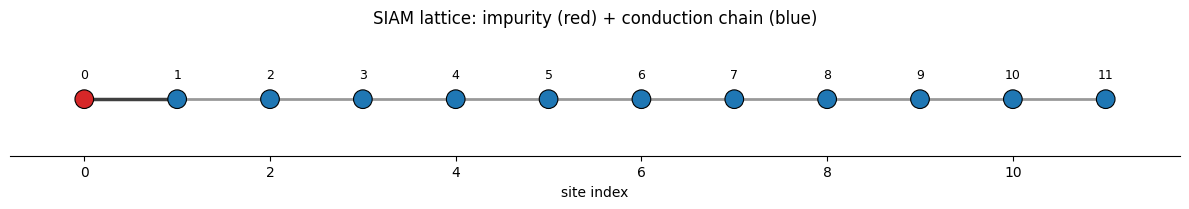

In [ ]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(12, 2.2))

# 导带内部边（将 chain 的局部索引映射到全局站点 1..L）
for i_local, j_local in chain.edges():
    ax.plot(
        [i_local + conduction_offset, j_local + conduction_offset],
        [0, 0],
        color="0.6",
        lw=2,
        zorder=1,
    )

# 杂质-导带首站点混成边
ax.plot([impurity_site, c0_site], [0, 0], color="0.25", lw=2.5, zorder=2)

# 节点着色：杂质红色，其它导带蓝色
x = np.arange(n_orbitals)
y = np.zeros(n_orbitals)
node_colors = ["tab:red"] + ["tab:blue"] * L
ax.scatter(x, y, c=node_colors, s=180, edgecolors="black", linewidths=0.8, zorder=3)

for site in range(n_orbitals):
    ax.text(site, 0.08, str(site), ha="center", va="bottom", fontsize=9)

ax.set_yticks([])
ax.set_xlabel("site index")
ax.set_title("SIAM lattice: impurity (red) + conduction chain (blue)")
ax.set_xlim(-0.8, n_orbitals - 0.2)
ax.set_ylim(-0.25, 0.3)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

## 6) 严格对角化（ED）

参照 `lattice-fermions.ipynb` 的思路：先把哈密顿量转为稀疏矩阵，再用 `scipy.sparse.linalg.eigsh` 求低能本征值。

注意：对 10 个 site 的自旋费米子，若不固定粒子数，Hilbert 空间仍可能较大。这里在固定粒子数扇区做严格对角化。

In [ ]:
from math import comb
from scipy.sparse.linalg import eigsh
from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd

# 直接复用第 3 段已构造好的 H（其 Hilbert 空间已固定粒子数）
N_up_ed, N_dn_ed = N_up, N_dn
sector_dim = comb(n_orbitals, N_up_ed) * comb(n_orbitals, N_dn_ed)
max_dim_for_sparse_ed = 2000000  # 经验阈值，可按机器内存调整

print("ED sector (N_up, N_dn) =", (N_up_ed, N_dn_ed))
print("Estimated Hilbert dimension =", sector_dim)

if sector_dim > max_dim_for_sparse_ed:
    print(
        "[Skip ED] 该扇区维度过大，不执行 to_sparse()/eigsh 以避免内存溢出。"
    )
    print("建议: 减小粒子数（如 1,1 或 2,2）后再做严格对角化。")
else:
    H_ed = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(H)
    sp_h = H_ed.to_sparse()
    eig_vals, eig_vecs = eigsh(sp_h, k=4, which="SA")
    eig_vals = np.sort(np.real(eig_vals))

    print("Hilbert dimension in this sector =", sp_h.shape[0])
    print("Exact ground-state energy E0 =", eig_vals[0])
    print("Lowest 4 eigenvalues =", eig_vals)

ED sector (N_up, N_dn) = (6, 6)
Estimated Hilbert dimension = 853776
Hilbert dimension in this sector = 853776
Exact ground-state energy E0 = -3.1718488273452503
Lowest 4 eigenvalues = [-3.17184883 -3.17083428 -3.14127319 -3.14122398]


Computing G from ED ground state, size 24x24...
Done computing G.


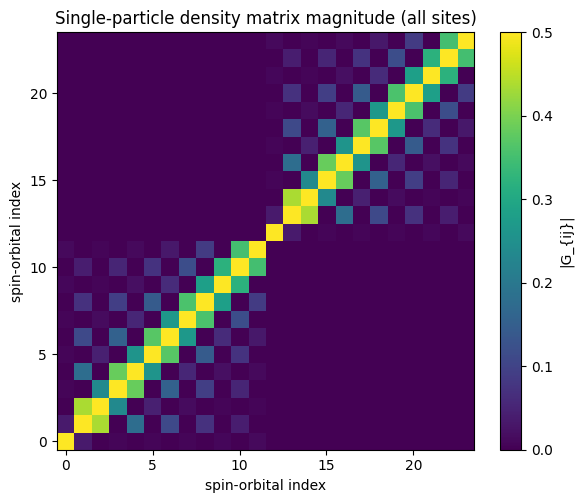

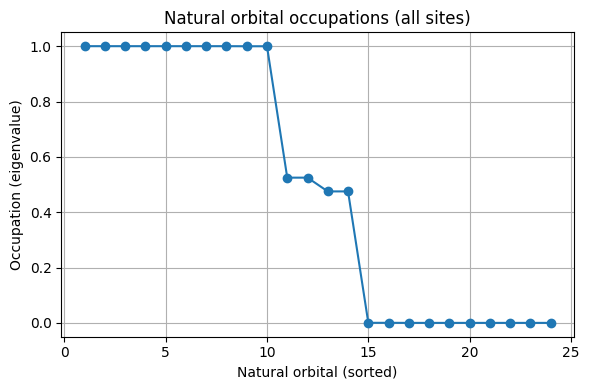

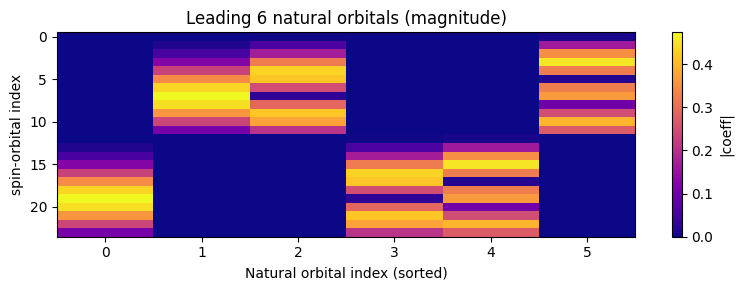

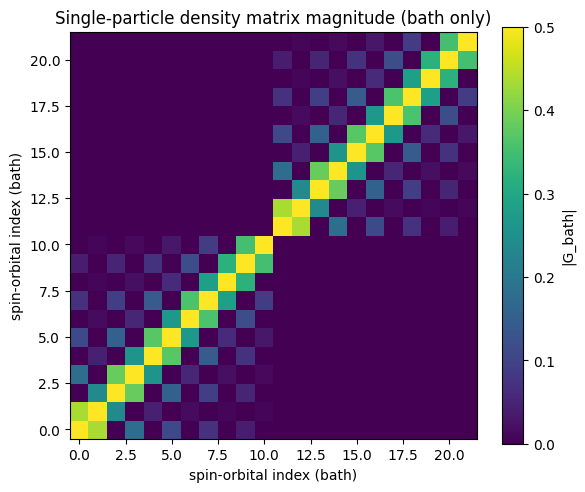

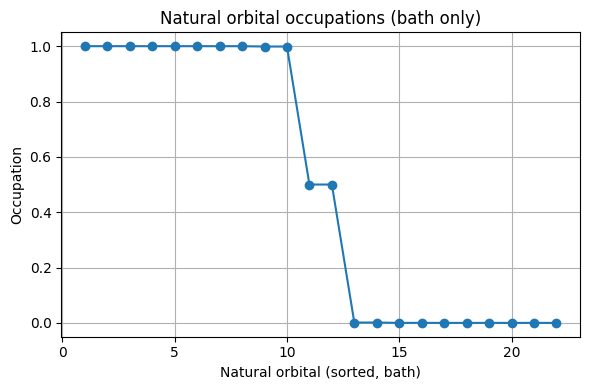

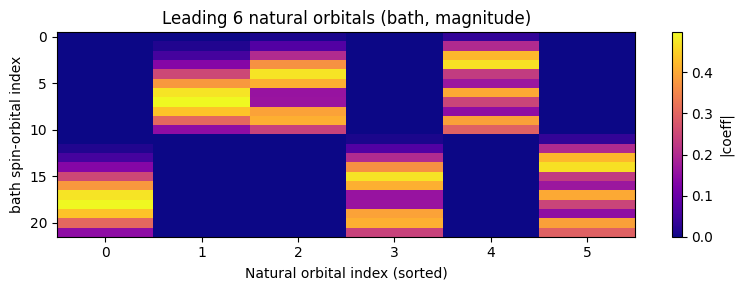

In [ ]:
# --- 从 ED 基态构造单体密度矩阵并绘图（全体 & 去除杂质） ---
import numpy as np
import matplotlib.pyplot as plt
from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd
from netket.operator.fermion import create as cdag, destroy as c

# 取 ED 基态向量（eig_vecs 应在前一单元中生成）
psi0 = eig_vecs[:, 0]
n_orb = hi.n_orbitals
n_ob = 2 * n_orb
print(f"Computing G from ED ground state, size {n_ob}x{n_ob}...")

# 仅计算同自旋块以避免转换 spin-flip 运算符时出错
G = np.zeros((n_ob, n_ob), dtype=np.complex128)
for sz in (+1, -1):
    off = 0 if sz == +1 else n_orb
    for i in range(n_orb):
        for j in range(n_orb):
            op = cdag(hi, i, sz=sz) @ c(hi, j, sz=sz)
            op_ed = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(op)
            sp = op_ed.to_sparse()
            G[off + i, off + j] = psi0.conj().T @ (sp @ psi0)

print('Done computing G.')

# 1) 全体格点：矩阵分布、对角化、自然轨道与占据数（降序）
plt.figure(figsize=(6,5))
plt.imshow(np.abs(G), origin='lower', cmap='viridis')
plt.colorbar(label='|G_{ij}|')
plt.title('Single-particle density matrix magnitude (all sites)')
plt.xlabel('spin-orbital index')
plt.ylabel('spin-orbital index')
plt.tight_layout()
plt.show()

evals, evecs = np.linalg.eigh(G)
order = np.argsort(-evals.real)
evals_sorted = evals[order].real
evecs_sorted = evecs[:, order]

plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(evals_sorted)+1), evals_sorted, 'o-')
plt.xlabel('Natural orbital (sorted)')
plt.ylabel('Occupation (eigenvalue)')
plt.title('Natural orbital occupations (all sites)')
plt.grid(True)
plt.tight_layout()
plt.show()

n_show = min(6, evecs_sorted.shape[1])
plt.figure(figsize=(8,3))
plt.imshow(np.abs(evecs_sorted[:, :n_show]), aspect='auto', cmap='plasma')
plt.colorbar(label='|coeff|')
plt.xlabel('Natural orbital index (sorted)')
plt.ylabel('spin-orbital index')
plt.title(f'Leading {n_show} natural orbitals (magnitude)')
plt.tight_layout()
plt.show()

# 2) 去掉杂质后的子空间（仅 bath）并重复分析
imp = impurity_site
bath_orbs = [k for k in range(n_orb) if k != imp]
bath_indices = [k for k in bath_orbs] + [k + n_orb for k in bath_orbs]
G_bath = G[np.ix_(bath_indices, bath_indices)]

plt.figure(figsize=(6,5))
plt.imshow(np.abs(G_bath), origin='lower', cmap='viridis')
plt.colorbar(label='|G_bath|')
plt.title('Single-particle density matrix magnitude (bath only)')
plt.xlabel('spin-orbital index (bath)')
plt.ylabel('spin-orbital index (bath)')
plt.tight_layout()
plt.show()

evals_b, evecs_b = np.linalg.eigh(G_bath)
order_b = np.argsort(-evals_b.real)
evals_b_sorted = evals_b[order_b].real
evecs_b_sorted = evecs_b[:, order_b]

plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(evals_b_sorted)+1), evals_b_sorted, 'o-')
plt.xlabel('Natural orbital (sorted, bath)')
plt.ylabel('Occupation')
plt.title('Natural orbital occupations (bath only)')
plt.grid(True)
plt.tight_layout()
plt.show()

n_show_b = min(6, evecs_b_sorted.shape[1])
plt.figure(figsize=(8,3))
plt.imshow(np.abs(evecs_b_sorted[:, :n_show_b]), aspect='auto', cmap='plasma')
plt.colorbar(label='|coeff|')
plt.xlabel('Natural orbital index (sorted)')
plt.ylabel('bath spin-orbital index')
plt.title(f'Leading {n_show_b} natural orbitals (bath, magnitude)')
plt.tight_layout()
plt.show()

# 输出结果到变量，便于后续使用
G_matrix = G
G_bath_matrix = G_bath
natural_occupations_all = evals_sorted
natural_occupations_bath = evals_b_sorted

### SIAM 哈密顿量（LaTeX 表达式）及自然轨道基下的变换

下面给出本 notebook 中使用的单杂质安德森模型（SIAM）哈密顿量的公式：

$$
H = U\,(n_{d\uparrow}-\tfrac{1}{2})(n_{d\downarrow}-\tfrac{1}{2})
\; + \; V\sum_{\sigma=\uparrow,\downarrow}\left(d^{\dagger}_{\sigma}\,c_{0\sigma} + c^{\dagger}_{0\sigma}\,d_{\sigma}\right)
\; + \; \sum_{\sigma=\uparrow,\downarrow}\sum_{i=1}^{L-1} t_i\left(c^{\dagger}_{i\sigma}\,c_{i-1,\sigma} + \mathrm{h.c.}\right)
$$

下面写出把算符从原局域自旋轨道基 $\{c_{p\sigma}\}$ 变换到自然轨道基 $\{a_{\alpha\sigma}\}$ 的通用单体线性变换：

$$
a_{\alpha\sigma} = \sum_{p} U_{p\alpha}\,c_{p\sigma},\qquad c_{p\sigma} = \sum_{\alpha} U^{*}_{p\alpha}\,a_{\alpha\sigma},
$$

其中 $U$ 为从原基到自然轨道基的酉变换矩阵（由格林函数对角化得到的本征向量构成列向量）。下述给出两种情形的哈密顿量形式：

**情形 A：对全体自旋轨道（含杂质）做自然轨道变换**

- 1 体项（动能、跃迁、混成在一体项中可统一写作）在新基下的形式：

$$
H_{1} = \sum_{pq,\sigma} h_{pq}\,c^{\dagger}_{p\sigma}c_{q\sigma}
= \sum_{\alpha\beta,\sigma} h'_{\alpha\beta}\,a^{\dagger}_{\alpha\sigma}a_{\beta\sigma},
\\
h' = U^{\dagger} h \, U,
$$

- 杂质的库仑 2 体项在自然轨道基中将变成一般的二体（四指标）形式。例如原项 $U(n_{d\uparrow}-\tfrac12)(n_{d\downarrow}-\tfrac12)$ 可写为：

$$
H_{U} = U\left(\sum_{\alpha\beta} U^{*}_{d\alpha}U_{d\beta}a^{\dagger}_{\alpha\uparrow}a_{\beta\uparrow}-\tfrac12\right)\left(\sum_{\gamma\delta} U^{*}_{d\gamma}U_{d\delta}a^{\dagger}_{\gamma\downarrow}a_{\delta\downarrow}-\tfrac12\right),
$$

这会展开为包含诸多 $a^{\dagger}a^{\dagger}aa$ 型项的等价二体相互作用（在数值上可按展开后的系数构造）。

- 因此总体在自然轨道基下的哈密顿量写为：

$$
H = \sum_{\alpha\beta,\sigma} h'_{\alpha\beta}\,a^{\dagger}_{\alpha\sigma}a_{\beta\sigma} \, + \, \frac{1}{2}\sum_{\alpha\beta\gamma\delta}\sum_{\sigma\sigma'} V_{\alpha\beta\gamma\delta}^{\,\sigma\sigma'}\,a^{\dagger}_{\alpha\sigma}a^{\dagger}_{\beta\sigma'}a_{\gamma\sigma'}a_{\delta\sigma},
$$

其中四指标相互作用张量 $V_{\alpha\beta\gamma\delta}^{\,\sigma\sigma'}$ 可由原始局域相互作用与 $U$ 的展开系数得到。

**情形 B：仅对导带（bath）站点做自然轨道变换，杂质轨道保持不变**

记原导带局域算符为 $c_{i\sigma}$（局部索引 $i$，其中 $i=0$ 为首站点与杂质混成），把导带轨道变换为新的导带自然轨道 $b_{m\sigma}$：

$$
b_{m\sigma} = \sum_{i\in\mathrm{bath}} W_{i m}\,c_{i\sigma},\qquad c_{i\sigma}=\sum_{m} W^{*}_{i m}\,b_{m\sigma},
$$

这里 $W$ 是仅在导带子空间上的酉矩阵；杂质算符仍用 $d_{\sigma}$ 表示。变换后各项：

- 混成项：

$$
V\sum_{\sigma}\left(d^{\dagger}_{\sigma}c_{0\sigma}+\mathrm{h.c.}\right)
= V\sum_{\sigma}\sum_{m} W^{*}_{0m}\,d^{\dagger}_{\sigma}b_{m\sigma} + \mathrm{h.c.},
$$

因此混成耦合分布到各个导带自然轨道，耦合强度为 $V\,W^{*}_{0m}$.

- 导带的 1 体项（动能/跃迁）在新导带基下为：

$$
H_{\mathrm{bath},1} = \sum_{ij\in\mathrm{bath},\sigma} h_{ij}\,c^{\dagger}_{i\sigma}c_{j\sigma}
= \sum_{mn,\sigma} h^{(b)}_{mn}\,b^{\dagger}_{m\sigma}b_{n\sigma},\\
h^{(b)} = W^{\dagger} h^{(\mathrm{bath})} W.
$$

- 杂质库仑项保持局域（形式不变），但若需要以导带自然轨道表示杂质电子与导带电子的二体耦合，也可展开得到相应的四指标项。

总结：

- 对全体站点做自然轨道变换会将一体项对角化或带来紧耦合的一体矩阵 $h'$，但会把局域 $U$ 项展开成广泛的四指标二体相互作用；

- 仅对导带做变换（杂质保持不变）则更为实用：一体项在导带上可能变简单（如对角化），混成项变为 $V W^{*}_{0m}$ 的形式，杂质的局域交互仍保留在局域形式，从而便于数值处理与截断。

In [ ]:
# --- 数值实现：两种变换后哈密顿量的构造（Case A & Case B） ---
import numpy as np
from scipy.linalg import block_diag
from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd
from netket.operator.fermion import create as cdag, destroy as c

# 准备：空间一体矩阵 h（不含自旋），按之前构造 H 的方式重建 hopping 与 hybridization
n_orb = hi.n_orbitals
h_spatial = np.zeros((n_orb, n_orb), dtype=float)

# 杂质-导带混成 (impurity_site <-> c0_site)
c0_site = conduction_offset
h_spatial[impurity_site, c0_site] += V
h_spatial[c0_site, impurity_site] += V

# 导带链 hopping（复用 chain 和 ti 计算）
for i_local, j_local in chain.edges():
    left_local, right_local = sorted((i_local, j_local))
    t_bond = ti[left_local]
    left_site = left_local + conduction_offset
    right_site = right_local + conduction_offset
    h_spatial[left_site, right_site] += t_bond
    h_spatial[right_site, left_site] += t_bond

# 将空间一体矩阵扩展为自旋轨道基（上/下块相同）
h_spin = block_diag(h_spatial, h_spatial)  # shape (n_ob, n_ob)
n_ob = h_spin.shape[0]

# 把局域 U 写成自旋轨道四指标张量的原始表示（只有 impurity_up, impurity_dn 处非零）
U_coul = U  # 使用环境中的 U 值
imp_up = impurity_site
imp_dn = impurity_site + n_orb
V_orig = np.zeros((n_ob, n_ob, n_ob, n_ob), dtype=complex)
# 对于局域 Hubbard U：非零成分为 <p q | V | r s> 对应 p=imp_up, q=imp_dn, r=imp_dn, s=imp_up
V_orig[imp_up, imp_dn, imp_dn, imp_up] = U_coul

# 为保证粒子数在每个自旋扇区内守恒，构造不混自旋的酉变换：
# 从之前计算的格林函数中提取自旋上块的自然轨道作为空间变换矩阵 U_spatial
if 'G_matrix' not in globals():
    raise RuntimeError('需要先计算单体密度矩阵 G 并保存为 G_matrix。请先运行包含 G 计算的单元。')
# 上自旋块（空间维度 n_orb）
G_up = G_matrix[:n_orb, :n_orb]
eig_sp, evec_sp = np.linalg.eigh(G_up)
order_sp = np.argsort(-eig_sp.real)
U_spatial = evec_sp[:, order_sp]  # 列为空间自然轨道
# 将空间变换嵌入自旋轨道基：U_spin = block_diag(U_spatial, U_spatial)（不混自旋）
U_spin = block_diag(U_spatial, U_spatial)  # shape (n_ob, n_ob)

# --- Case A: 全站点自然轨道变换（不混自旋）
h_A = U_spin.conj().T @ h_spin @ U_spin
print('Case A: full-site transform (spin-block-diag): h_A shape =', h_A.shape)
print('h_A diagonal (first 8) =', np.round(np.diag(h_A)[:8], 6))

# 二体项变换（四指标张量）: V'_{ABCD} = sum_{pqrs} U*_{pA} U*_{qB} V_{pqrs} U_{rC} U_{sD}
# 由于 U_spin 为自旋块对角，变换不会破坏自旋扇区粒子数守恒
V_A = np.einsum('pA,qB,pqrs->ABrs', U_spin.conj(), U_spin.conj(), V_orig)
V_A = np.einsum('rC,ABrs->ABC s', U_spin, V_A).reshape(n_ob,n_ob,n_ob,n_ob)
# 显示 V_A 中与新基下对应 impurity 的若干分量示例
print('Case A: sample V_A element [0,1,1,0] =', V_A[0,1,1,0])

# --- Case B: 仅对导带（bath）做自然轨道变换，杂质保持不变 ---
if 'G_bath_matrix' not in globals():
    raise RuntimeError('需要先计算 G_bath 并保存为 G_bath_matrix。请先运行包含 G_bath 计算的单元。')
# bath spatial 维度为 n_orb-1，G_bath 矩阵的上半块对应 bath 的上自旋部分
n_bath = n_orb - 1
G_bath_up = G_bath_matrix[:n_bath, :n_bath]
eig_b, evec_b = np.linalg.eigh(G_bath_up)
order_b = np.argsort(-eig_b.real)
W_spatial = evec_b[:, order_b]  # bath 空间自然轨道
# 嵌入到完整自旋轨道基：对上/下自旋分别插入 W_spatial
U_full_B = np.eye(n_ob, dtype=complex)
# bath 空间索引（按先上后下排列），与之前 bath_indices 的定义一致
bath_indices = [k for k in range(n_orb) if k != impurity_site]
bath_spin_indices_up = bath_indices
bath_spin_indices_dn = [k + n_orb for k in bath_indices]
U_full_B[np.ix_(bath_spin_indices_up, bath_spin_indices_up)] = W_spatial
U_full_B[np.ix_(bath_spin_indices_dn, bath_spin_indices_dn)] = W_spatial
# 保持 impurity 两个自旋轨道不变（对应 U_full_B 的对角为 1）
h_B = U_full_B.conj().T @ h_spin @ U_full_B
print('Case B: bath-only transform (spin-block-diag embed): h_B shape =', h_B.shape)
print('h_B diagonal (first 8) =', np.round(np.diag(h_B)[:8], 6))

# 二体在 Case B 下的变换（仍使用完整嵌入矩阵 U_full_B）
V_B = np.einsum('pA,qB,pqrs->ABrs', U_full_B.conj(), U_full_B.conj(), V_orig)
V_B = np.einsum('rC,ABrs->ABC s', U_full_B, V_B).reshape(n_ob,n_ob,n_ob,n_ob)
print('Case B: sample V_B element [0,1,1,0] =', V_B[0,1,1,0])

# 保存结果以便后续使用
h_trans_full = h_A
V_trans_full = V_A
h_trans_bath = h_B
V_trans_bath = V_B

# 小提示：U_spin 与 U_full_B 均为自旋块对角，因此任何用这些张量重建的算符都会在每个自旋扇区内保持粒子数守恒，能够被 ParticleNumberAndSpinConservingFermioperator2nd 正确转换。
print('Done: transformed Hamiltonian tensors ready (with spin-block-diagonal transforms).')

Case A: full-site transform (spin-block-diag): h_A shape = (24, 24)
h_A diagonal (first 8) = [-0.176032+0.j -0.232766+0.j -0.264527+0.j -0.259806+0.j -0.156345+0.j
 -0.0247  +0.j  0.0247  +0.j  0.156345+0.j]
Case A: sample V_A element [0,1,1,0] = 0j
Case B: bath-only transform (spin-block-diag embed): h_B shape = (24, 24)
h_B diagonal (first 8) = [ 0.      +0.j -0.13672 +0.j -0.190229+0.j -0.22093 +0.j -0.226372+0.j
 -0.306333+0.j  0.      +0.j  0.306333+0.j]
Case B: sample V_B element [0,1,1,0] = 0j
Done: transformed Hamiltonian tensors ready (with spin-block-diagonal transforms).


In [ ]:
# --- 验证：用变换后张量重建哈密顿量并比较能谱（原始 vs Case A vs Case B） ---
import numpy as np
from scipy.sparse.linalg import eigsh
from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd
from netket.operator.fermion import create as cdag, destroy as c, number as nc
from scipy.linalg import block_diag

tol = 1e-12
n_orb = hi.n_orbitals
n_ob = 2 * n_orb

def idx_to_site_spin(idx):
    if idx < n_orb:
        return int(idx), +1
    else:
        return int(idx - n_orb), -1

def build_one_body_operator_from_h(h_mat):
    # Accept either spatial h (n_orb x n_orb) or spin-orbital h (2*n_orb x 2*n_orb)
    s = h_mat.shape
    if s[0] == n_orb and s[1] == n_orb:
        h_full = block_diag(h_mat, h_mat)
    elif s[0] == 2 * n_orb and s[1] == 2 * n_orb:
        h_full = h_mat
    else:
        raise RuntimeError(f'Unexpected one-body matrix shape {s}; expected ({n_orb},{n_orb}) or ({2*n_orb},{2*n_orb}).')
    Hop = 0.0
    for p in range(h_full.shape[0]):
        for q in range(h_full.shape[1]):
            coeff = h_full[p, q]
            if abs(coeff) < tol:
                continue
            sp_p, sz_p = idx_to_site_spin(p)
            sp_q, sz_q = idx_to_site_spin(q)
            Hop += coeff * (cdag(hi, sp_p, sz=sz_p) @ c(hi, sp_q, sz=sz_q))
    return Hop

# 参考稀疏矩阵 sp_h（若尚未计算则从已定义的 H 构造）
if 'sp_h' not in globals():
    print('Reference sparse H not found; constructing from original H via operator.to_sparse()...')
    sp_h = H.to_sparse()
else:
    print('Using existing sp_h from notebook scope.')

# 构造 Case A (spin-block-diag U_spin 已在前面单元计算)
if 'U_spin' not in globals():
    raise RuntimeError('需要先计算 U_spin（全体自旋轨道不混自旋的酉）。请先运行包含 U_spin 的单元。')

# 一体项
H_A_one = build_one_body_operator_from_h(h_trans_full)
# 用变换后的酉构造杂质数算符并重建 U 项（避免直接展开四阶张量）
imp_up = impurity_site
imp_dn = impurity_site + n_orb
up_idxs = np.arange(0, n_orb)
dn_idxs = np.arange(n_orb, n_ob)

# 计算 v_up_p = sum_alpha U_{p,alpha} * U_{d,alpha} （p 对应上自旋空间索引）
U = U_spin  # 简写
v_up = (U[up_idxs, :] * U[imp_up, :]).sum(axis=1)
M_up = np.outer(np.conj(v_up), v_up)  # 空间一体矩阵系数（上自旋）
n_up_op = 0.0
for i_p, p in enumerate(up_idxs):
    for i_q, q in enumerate(up_idxs):
        coeff = M_up[i_p, i_q]
        if abs(coeff) < tol:
            continue
        n_up_op += coeff * (cdag(hi, p, sz=+1) @ c(hi, q, sz=+1))

# 下自旋类似
v_dn = (U[dn_idxs, :] * U[imp_dn, :]).sum(axis=1)
M_dn = np.outer(np.conj(v_dn), v_dn)
n_dn_op = 0.0
for i_p, p in enumerate(dn_idxs):
    for i_q, q in enumerate(dn_idxs):
        coeff = M_dn[i_p, i_q]
        if abs(coeff) < tol:
            continue
        n_dn_op += coeff * (cdag(hi, p, sz=-1) @ c(hi, q, sz=-1))

H_A_U = U * (n_up_op - 0.5) @ (n_dn_op - 0.5)
H_A_op = H_A_one + H_A_U

# 构造 Case B：一体项直接用 h_trans_bath；U 项保持局域不变（impurity 未变）
H_B_one = build_one_body_operator_from_h(h_trans_bath)
H_B_U = U * (nc(hi, impurity_site, sz=+1) - 0.5) @ (nc(hi, impurity_site, sz=-1) - 0.5)
H_B_op = H_B_one + H_B_U

# 把它们转为稀疏矩阵并做 ED（只求前几低能）
print('Converting Case A operator to sparse using FermionOperator.to_sparse()...')
try:
    sp_A = H_A_op.to_sparse()
except Exception as e:
    raise RuntimeError('直接从 FermionOperator2nd.to_sparse() 构造 Case A 的稀疏矩阵失败: '+str(e)) from e
print('Converting Case B operator to sparse using FermionOperator.to_sparse()...')
try:
    sp_B = H_B_op.to_sparse()
except Exception as e:
    raise RuntimeError('直接从 FermionOperator2nd.to_sparse() 构造 Case B 的稀疏矩阵失败: '+str(e)) from e

k = min(6, sp_h.shape[0]-2)
print('Computing lowest', k, 'eigenvalues for each Hamiltonian (this may take time)...')
vals_ref, _ = eigsh(sp_h, k=k, which='SA')
vals_A, _ = eigsh(sp_A, k=k, which='SA')
vals_B, _ = eigsh(sp_B, k=k, which='SA')
vals_ref = np.sort(np.real(vals_ref))
vals_A = np.sort(np.real(vals_A))
vals_B = np.sort(np.real(vals_B))

print('Reference lowest eigenvalues:', np.round(vals_ref, 8))
print('Case A lowest eigenvalues    :', np.round(vals_A, 8))
print('Case B lowest eigenvalues    :', np.round(vals_B, 8))

# 比较并断言相等（允许小的数值误差）
tol_spec = 1e-8
eq_A = np.allclose(vals_ref, vals_A, atol=tol_spec, rtol=0)
eq_B = np.allclose(vals_ref, vals_B, atol=tol_spec, rtol=0)
print('Case A spectrum matches reference within tol', tol_spec, ':', eq_A)
print('Case B spectrum matches reference within tol', tol_spec, ':', eq_B)

print('max|ref - A| =', np.max(np.abs(vals_ref - vals_A)))
print('max|ref - B| =', np.max(np.abs(vals_ref - vals_B)))

Using existing sp_h from notebook scope.


IndexError: requested orbital index `orb=12,sz=-1` outside of the hilbert space `SpinOrbitalFermions(n_orbitals=12, s=1/2, n_fermions=12, n_fermions_per_spin=(6, 6))`

In [ ]:
import jax
import jax.numpy as jnp
import flax.linen as nn
from functools import partial

from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd

# ========= Reproducibility seeds =========
SEED_MODEL_SLATER = 11
SEED_SAMPLER_SLATER = 101
SEED_MODEL_NJ = 22
SEED_SAMPLER_NJ = 202
SEED_MODEL_BF = 33
SEED_SAMPLER_BF = 303

# 给采样器构造“空间轨道图”：杂质-首导带 + 导带链最近邻
sampler_edges = [(impurity_site, c0_site)]
sampler_edges += [
    (min(i, j) + conduction_offset, max(i, j) + conduction_offset)
    for (i, j) in chain.edges()
 ]
graph_sampler = nk.graph.Graph(edges=sampler_edges, n_nodes=n_orbitals)

# 如果第 6 段已执行，则直接复用基准能量；否则临时算一次（用于后续误差对比）
if "eig_vals" in globals():
    E_gs = float(np.sort(np.real(eig_vals))[0])
else:
    H_ref = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(H)
    from scipy.sparse.linalg import eigsh
    ref_vals, _ = eigsh(H_ref.to_sparse(), k=2, which="SA")
    E_gs = float(np.sort(np.real(ref_vals))[0])

print("reference E_gs =", E_gs)
print("sampler graph nodes/edges =", graph_sampler.n_nodes, graph_sampler.n_edges)
print(
    "seeds:",
    (SEED_MODEL_SLATER, SEED_SAMPLER_SLATER, SEED_MODEL_NJ, SEED_SAMPLER_NJ, SEED_MODEL_BF, SEED_SAMPLER_BF),
)

reference E_gs = -3.1718488273452383
sampler graph nodes/edges = 12 11
seeds: (11, 101, 22, 202, 33, 303)


### 7.1 Slater 行列式

对固定粒子数费米体系，Slater 态可写为占据轨道子矩阵行列式。优化目标是最小化
$ E(\theta)=\langle\Psi_\theta|H|\Psi_\theta\rangle/\langle\Psi_\theta|\Psi_\theta\rangle $。

这里采用与教程一致的 VMC+SR 框架。

In [ ]:
class LogSlaterDeterminant(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    @nn.compact
    def __call__(self, n):
        # 直接复用 NetKet 内建 Slater2nd（限制在固定粒子数子空间）
        return nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=True, param_dtype=float
        )(n)

model_slater = LogSlaterDeterminant(hi)
sa_slater = nk.sampler.MetropolisFermionHop(
    hi, graph=graph_sampler, spin_symmetric=True
 )
vstate_slater = nk.vqs.MCState(
    sa_slater,
    model_slater,
    n_samples=2**13,
    n_discard_per_chain=16,
    seed=SEED_MODEL_SLATER,
    sampler_seed=SEED_SAMPLER_SLATER,
 )

op_slater = nk.optimizer.Sgd(learning_rate=0.05)
gs_slater = nk.driver.VMC_SR(
    H, op_slater, variational_state=vstate_slater, diag_shift=0.05, mode="real"
 )

slater_log = nk.logging.RuntimeLog()
gs_slater.run(n_iter=300, out=slater_log)

E_slater = vstate_slater.expect(H)
err_slater = abs((E_slater.mean - E_gs) / E_gs)
print(f"Slater optimized energy: {E_slater}")
print(f"Slater relative error  : {err_slater}")

Automatic SR implementation choice:  QGT


  0%|          | 0/300 [00:00<?, ?it/s]

Slater optimized energy: -2.280+0.000j ± 0.014 [σ²=1.0e+00, R̂=1.002]
Slater relative error  : 0.2812267457252616


### 7.2 Neural Jastrow-Slater

在 Slater 振幅外再乘一个神经网络 Jastrow 因子：
$ \log\Psi(\mathbf{n}) = \log\Phi_{\mathrm{Slater}}(\mathbf{n}) + J_\theta(\mathbf{n}) $.

它主要增强相关性描述（尤其是振幅模值部分）。

In [ ]:
class LogNeuralJastrowSlater(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = N

    @nn.compact
    def __call__(self, n):
        log_slater = nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=True, param_dtype=float
        )(n)

        x = n.astype(jnp.float32)
        j = nn.Dense(self.hidden_units)(x)
        j = jax.nn.tanh(j)
        j = nn.Dense(1)(j).squeeze(-1)
        return log_slater + j

model_nj = LogNeuralJastrowSlater(hi, hidden_units=max(32, 2 * n_orbitals))
sa_nj = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
vstate_nj = nk.vqs.MCState(
    sa_nj,
    model_nj,
    n_samples=2**13,
    n_discard_per_chain=16,
    seed=SEED_MODEL_NJ,
    sampler_seed=SEED_SAMPLER_NJ,
 )
nj_p = vstate_nj.n_parameters
print(f" [NJ] Params: {nj_p}")

op_nj = nk.optimizer.Sgd(learning_rate=0.05)
gs_nj = nk.driver.VMC_SR(
    H, op_nj, variational_state=vstate_nj, diag_shift=0.05, mode="real"
 )

nj_log = nk.logging.RuntimeLog()
gs_nj.run(n_iter=300, out=nj_log)

E_nj = vstate_nj.expect(H)
err_nj = abs((E_nj.mean - E_gs) / E_gs)
print(f"Neural Jastrow-Slater optimized energy: {E_nj}")
print(f"Neural Jastrow-Slater relative error  : {err_nj}")

 [NJ] Params: 905
Automatic SR implementation choice:  QGT


  0%|          | 0/300 [00:00<?, ?it/s]

Neural Jastrow-Slater optimized energy: -3.1446+0.0000j ± 0.0012 [σ²=7.7e-03, R̂=1.003]
Neural Jastrow-Slater relative error  : 0.008583703855451019


### 7.3 Neural Backflow

Backflow 的思想是把 Slater 轨道矩阵推广为构型依赖：
$ M^{\mathrm{bf}}(\mathbf{n})=M+F_\theta(\mathbf{n})$ .

下面给出与教程同类型的“加性 backflow”实现：神经网络输出与轨道矩阵同形状的修正项。

In [ ]:
class LogNeuralBackflow(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = N

    @nn.compact
    def __call__(self, n):
        n_orb = self.hilbert.n_orbitals
        n_spin = self.hilbert.n_spin_subsectors
        nfs = self.hilbert.n_fermions_per_spin[0]

        # 限制型 HF 基轨道（所有自旋扇区共享）
        M = self.param(
            "M",
            nn.initializers.lecun_normal(),
            (n_orb, nfs),
            float,
        )

        # Backflow 网络：输出 (n_spin, n_orb, nfs)
        x = n.astype(jnp.float32)
        F = nn.Dense(self.hidden_units)(x)
        F = jax.nn.tanh(F)
        F = nn.Dense(n_spin * n_orb * nfs)(F)
        F = F.reshape(F.shape[:-1] + (n_spin, n_orb, nfs))

        @partial(jnp.vectorize, signature="(m),(s,o,f)->()")
        def log_bf(n_one, F_one):
            R = n_one.nonzero(size=self.hilbert.n_fermions)[0]
            log_det_sum = 0.0 + 0.0j
            i_start = 0

            for i, nf_i in enumerate(self.hilbert.n_fermions_per_spin):
                if nf_i == 0:
                    continue
                R_i = R[i_start : i_start + nf_i] - i * n_orb
                A_i = (M + F_one[i])[R_i]
                log_det_sum = log_det_sum + nk.jax.logdet_cmplx(A_i)
                i_start += nf_i

            return log_det_sum

        return log_bf(n, F)

model_bf = LogNeuralBackflow(hi, hidden_units=max(32, 2 * n_orbitals))
sa_bf = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
vstate_bf = nk.vqs.MCState(
    sa_bf,
    model_bf,
    n_samples=2**13,
    n_discard_per_chain=16,
    seed=SEED_MODEL_BF,
    sampler_seed=SEED_SAMPLER_BF,
 )
bf_p = vstate_bf.n_parameters
print(f" [BF] Params: {bf_p}")

op_bf = nk.optimizer.Sgd(learning_rate=0.05)
gs_bf = nk.driver.VMC_SR(
    H, op_bf, variational_state=vstate_bf, diag_shift=0.05, mode="real"
 )

bf_log = nk.logging.RuntimeLog()
gs_bf.run(n_iter=300, out=bf_log)

E_bf = vstate_bf.expect(H)
err_bf = abs((E_bf.mean - E_gs) / E_gs)
print(f"Neural Backflow optimized energy: {E_bf}")
print(f"Neural Backflow relative error  : {err_bf}")

 [BF] Params: 5624
Automatic SR implementation choice:  QGT


  0%|          | 0/300 [00:00<?, ?it/s]

Neural Backflow optimized energy: -3.11502+0.00000j ± 0.00076 [σ²=3.1e-03, R̂=1.003]
Neural Backflow relative error  : 0.017917026676281263


### 7.4 结果汇总作图

和教程相同，把三种 ansatz 的优化能量曲线放在一张图中，并与 ED 基准能量比较。

### 扫描说明

- **用途**：扫描不同 `hidden_units` 下的 Neural Jastrow 与 Neural Backflow 的最终能量，并在同一张图中比较。
- **可调参数**：在代码单元中修改 `hidden_list`、`n_iter_scan`、`n_samples_scan` 以控制精度与运行时间。
- **运行提示**：每个配置会进行简化的 VMC 优化，可能耗时较长；建议先用较小的 `hidden_list` 和 `n_iter_scan` 进行快速试验。
- **输出**：绘制 `Energy vs hidden units` 曲线，并标注 ED 精确能量与 Slater 参考线（若可用）。


In [ ]:
# import netket as nk
# import numpy as np

# # 扫描不同 hidden units 下的 Neural Jastrow (NJ) 与 Neural Backflow (BF)
# hidden_list = [8, 16, 32, 64, 128]
# n_iter_scan = 150
# n_samples_scan = 2**12

# # 扩展 results 字典，增加存储历史数据和参数量的键
# results = {
#     'hidden': [], 
#     'nj_energy': [], 
#     'bf_energy': [],
#     'nj_histories': [], # 存储 NJ 每一步的能量均值
#     'bf_histories': [], # 存储 BF 每一步的能量均值
#     'nj_params': [],    # 存储 NJ 参数量
#     'bf_params': []     # 存储 BF 参数量
# }

# for h in hidden_list:
#     print(f'== hidden_units = {h} ==')
    
#     # --- Neural Jastrow ---
#     try:
#         model_nj_scan = LogNeuralJastrowSlater(hi, hidden_units=h)
#         sa_nj_scan = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
#         vstate_nj_scan = nk.vqs.MCState(sa_nj_scan, model_nj_scan, n_samples=n_samples_scan, n_discard_per_chain=16, seed=SEED_MODEL_NJ + h, sampler_seed=SEED_SAMPLER_NJ + h)
        
#         # 记录参数量
#         nj_p = vstate_nj_scan.n_parameters
#         results['nj_params'].append(nj_p)
#         print(f" [NJ] Params: {nj_p}")

#         opt_nj = nk.optimizer.Sgd(learning_rate=0.05)
#         # 创建 Logger
#         log_nj = nk.logging.RuntimeLog()
#         driver_nj = nk.driver.VMC_SR(H, opt_nj, variational_state=vstate_nj_scan, diag_shift=0.05, mode='real')
        
#         # 传入 out=log_nj 来记录历史
#         driver_nj.run(n_iter=n_iter_scan, out=log_nj)
        
#         # 提取历史能量均值
#         results['nj_histories'].append(log_nj.data['Energy']['Mean'])
        
#         E_nj_scan = vstate_nj_scan.expect(H)
#         nj_val = float(E_nj_scan.mean.real)
#     except Exception as e:
#         print('NJ scan failed for h=', h, '->', e)
#         nj_val = float('nan')
#         results['nj_histories'].append([])
#         results['nj_params'].append(0)

#     # --- Neural Backflow ---
#     try:
#         model_bf_scan = LogNeuralBackflow(hi, hidden_units=h)
#         sa_bf_scan = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
#         vstate_bf_scan = nk.vqs.MCState(sa_bf_scan, model_bf_scan, n_samples=n_samples_scan, n_discard_per_chain=16, seed=SEED_MODEL_BF + h, sampler_seed=SEED_SAMPLER_BF + h)
        
#         # 记录参数量
#         bf_p = vstate_bf_scan.n_parameters
#         results['bf_params'].append(bf_p)
#         print(f" [BF] Params: {bf_p}")

#         opt_bf = nk.optimizer.Sgd(learning_rate=0.05)
#         # 创建 Logger
#         log_bf = nk.logging.RuntimeLog()
#         driver_bf = nk.driver.VMC_SR(H, opt_bf, variational_state=vstate_bf_scan, diag_shift=0.05, mode='real')
        
#         # 传入 out=log_bf 来记录历史
#         driver_bf.run(n_iter=n_iter_scan, out=log_bf)
        
#         # 提取历史能量均值
#         results['bf_histories'].append(log_bf.data['Energy']['Mean'])
        
#         E_bf_scan = vstate_bf_scan.expect(H)
#         bf_val = float(E_bf_scan.mean.real)
#     except Exception as e:
#         print('BF scan failed for h=', h, '->', e)
#         bf_val = float('nan')
#         results['bf_histories'].append([])
#         results['bf_params'].append(0)

#     results['hidden'].append(h)
#     results['nj_energy'].append(nj_val)
#     results['bf_energy'].append(bf_val)


In [ ]:
# # 绘图：在同一张图中显示 NJ 与 BF 的能量随 hidden units 的变化，并标注 ED 与 Slater 基线
# from matplotlib import pyplot as plt
# plt.figure(figsize=(7,4))
# plt.plot(results['hidden'], results['nj_energy'], '-o', label='Neural Jastrow')
# plt.plot(results['hidden'], results['bf_energy'], '-s', label='Neural Backflow')
# plt.hlines(E_gs, xmin=min(results['hidden']), xmax=max(results['hidden']), colors='k', linestyles='--', label='ED exact')
# # 如果 Slater 能量存在，则绘制为参考线（可能之前已计算）
# try:
#     slater_val = float(E_slater.mean.real)
#     plt.hlines(slater_val, xmin=min(results['hidden']), xmax=max(results['hidden']), colors='gray', linestyles=':', label='Slater')
# except Exception:
#     pass

# plt.xscale('log', base=2)
# plt.xlabel('hidden units')
# plt.ylabel('Energy')
# plt.title('Energy vs hidden units: Neural Jastrow vs Neural Backflow')
# plt.legend()
# plt.grid(True)
# plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # 设置画布
# plt.figure(figsize=(12, 7))

# # 使用 colormap 生成一组颜色，确保不同 hidden units 之间有区分度
# colors = plt.cm.viridis(np.linspace(0, 0.9, len(hidden_list)))

# # 假设你在循环中已经将历史数据存入 results['nj_histories'] = [array1, array2, ...]
# # 如果你使用的是 NetKet 的 JsonLog 或 RuntimeLog，数据通常在 logger.data['Energy']['Mean']
# for i, h in enumerate(hidden_list):
#     # 绘制 Neural Jastrow 的收敛曲线 (虚线)
#     if 'nj_histories' in results and i < len(results['nj_histories']):
#         y_nj = results['nj_histories'][i]
#         plt.plot(y_nj, color=colors[i], linestyle='--', alpha=0.6, 
#                  label=f'NJ (h={h})')
    
#     # 绘制 Neural Backflow 的收敛曲线 (实线)
#     if 'bf_histories' in results and i < len(results['bf_histories']):
#         y_bf = results['bf_histories'][i]
#         plt.plot(y_bf, color=colors[i], linestyle='-', linewidth=1.5,
#                  label=f'BF (h={h})')

# # 绘制 ED 精确能量参考线
# if 'E_gs' in locals():
#     plt.axhline(y=E_gs, color='red', linestyle=':', label='Exact (ED)', alpha=0.8, zorder=0)

# # 图表修饰
# plt.title('Energy Convergence History: NJ vs BF', fontsize=14)
# plt.xlabel('Iteration', fontsize=12)
# plt.ylabel('Energy', fontsize=12)

# # 将图例放在右侧，避免遮挡收敛曲线
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, fontsize=9)

# plt.grid(True, which='both', linestyle=':', alpha=0.5)
# plt.tight_layout()
# plt.show()


In [ ]:
# import numpy as np

# # 遍历 hidden_list，将每个配置的收敛历史保存为独立的 txt 文件
# for i, h in enumerate(results['hidden']):
#     # --- 保存 Neural Jastrow (NJ) 历史 ---
#     nj_history = results['nj_histories'][i]
#     if len(nj_history) > 0:
#         filename_nj = f"energy_history_nj_h{h}.txt"
#         # 构造数据：第一列是迭代步数，第二列是能量均值
#         # 注意：使用 .real 确保保存的是实部
#         iters = np.arange(len(nj_history))
#         data_nj = np.column_stack((iters, np.array(nj_history).real))
        
#         # 保存文件，fmt 指定格式（整数步数，10位小数能量）
#         np.savetxt(filename_nj, data_nj, fmt='%d %.10f', 
#                    header=f"NJ hidden_units={h}\nIteration Energy_Mean")
#         print(f"已保存: {filename_nj}")

#     # --- 保存 Neural Backflow (BF) 历史 ---
#     bf_history = results['bf_histories'][i]
#     if len(bf_history) > 0:
#         filename_bf = f"energy_history_bf_h{h}.txt"
#         iters = np.arange(len(bf_history))
#         data_bf = np.column_stack((iters, np.array(bf_history).real))
        
#         np.savetxt(filename_bf, data_bf, fmt='%d %.10f', 
#                    header=f"BF hidden_units={h}\nIteration Energy_Mean")
#         print(f"已保存: {filename_bf}")

# # --- 额外步骤：保存一个汇总所有 hidden units 最终能量的摘要文件 ---
# summary_file = "summary_results.txt"
# # 准备汇总数据
# summary_table = np.column_stack((
#     results['hidden'],
#     results['nj_params'],
#     results['nj_energy'],
#     results['bf_params'],
#     results['bf_energy']
# ))

# np.savetxt(summary_file, summary_table, fmt='%d %d %.10f %d %.10f',
#            header="Hidden_Units NJ_Params NJ_Energy BF_Params BF_Energy")
# print(f"\n所有配置的最终结果已汇总至: {summary_file}")


C:\Users\yufei\AppData\Local\Temp\ipykernel_25288\3704902203.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


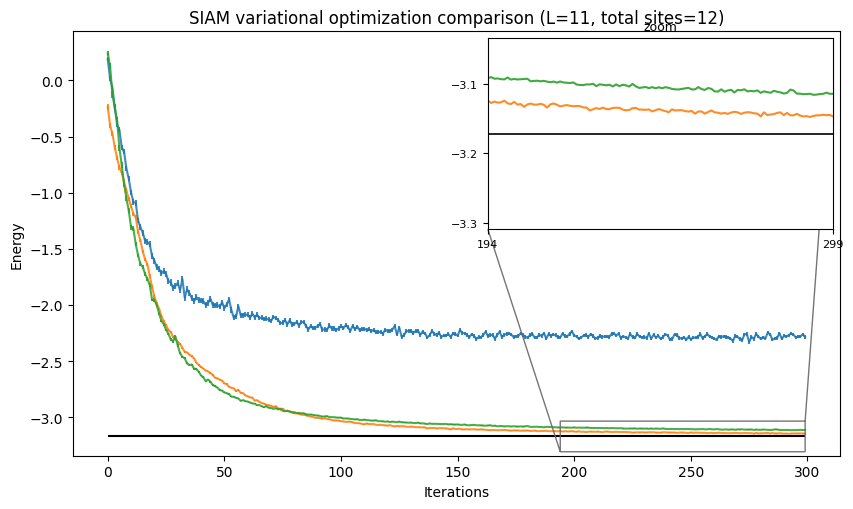

In [ ]:
logged_data = (slater_log.data, nj_log.data, bf_log.data)
labels = ("Slater", "Neural Jastrow", "Neural Backflow")

from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(figsize=(8.6, 5.2))
for data, label in zip(logged_data, labels):
    ax.errorbar(
        data["Energy"].iters,
        data["Energy"].Mean.real,
        yerr=data["Energy"].Sigma,
        label=label,
        alpha=0.85,
    )

iters_max = max(data["Energy"].iters[-1] for data in logged_data)
ax.hlines([E_gs], xmin=0, xmax=iters_max, color="black", label="ED Exact")

ax.set_xlabel("Iterations")
ax.set_ylabel("Energy")
ax.legend()
ax.set_title(f"SIAM variational optimization comparison (L={L}, total sites={n_orbitals})")

# inset: 放大末段迭代与接近 E_gs 的能量窗口
axins = inset_axes(ax, width="45%", height="45%", loc="upper right")
for data, _label in zip(logged_data, labels):
    axins.plot(data["Energy"].iters, data["Energy"].Mean.real, alpha=0.9)
axins.hlines([E_gs], xmin=0, xmax=iters_max, color="black", linewidth=1.2)

# 自动设置放大窗口（后 35% 迭代 + 更窄的 E_gs 邻域）
x1 = int(0.65 * iters_max)
x2 = int(iters_max)
all_means = np.concatenate([np.asarray(d["Energy"].Mean.real) for d in logged_data])
y_center = E_gs
y_span = max(1e-6, 0.04 * np.max(np.abs(all_means - y_center)))
axins.set_xlim(x1, x2)
axins.set_ylim(y_center - y_span, y_center + y_span)
axins.set_xticks([x1, x2])

# 打开并设置 inset 的 y 轴刻度
axins.yaxis.set_major_locator(MaxNLocator(nbins=3))
axins.tick_params(axis="y", labelsize=8)
axins.tick_params(axis="x", labelsize=8)
axins.set_title("zoom", fontsize=9)

# 使用 matplotlib 原生接口标注放大区域，连线更规整
ax.indicate_inset_zoom(axins, edgecolor="0.4", alpha=0.9)

plt.tight_layout()
plt.show()

## 8) 单体格林函数矩阵（自旋分辨）

这里采用自旋分辨定义：

$$
G_{(i,\sigma),(j,\sigma')}=\langle c^{\dagger}_{i\sigma}c_{j\sigma'}\rangle
$$

在当前 Hamiltonian 下无自旋翻转项，因此矩阵应呈块对角结构：

- 左上角 $N_{orb}\times N_{orb}$：自旋上块；
- 右下角 $N_{orb}\times N_{orb}$：自旋下块；
- 两个非对角自旋块应接近 0。

因此总矩阵维度是
$$
n_{ob}=2N_{orb},\quad G\in\mathbb{C}^{n_{ob}\times n_{ob}}.
$$
对你当前 $N_{orb}=12$，即 $G$ 为 $24\times24$。

Use variational state: vstate_bf


D:\Program Files\Python_lib\My_lib\Netket\netket\netket\operator\_fermion2nd\jax.py:557: UserWarning: 
Consider using `netket.experimental.operator.ParticleNumberAndSpinConservingFermioperator2nd` to reduce the number of connected elements and
considerably reduce the computational cost.
You can convert this operator by calling `netket.experimental.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd`.

  super()._setup(self)


G shape = (24, 24)
expected shape = (24, 24)
||G_up||_F = 2.4563617207113246
||G_dn||_F = 2.451397890408168
||G_updn||_F = 0.0
||G_dnup||_F = 0.0
max |G - G^†| = 0.09076778123472865


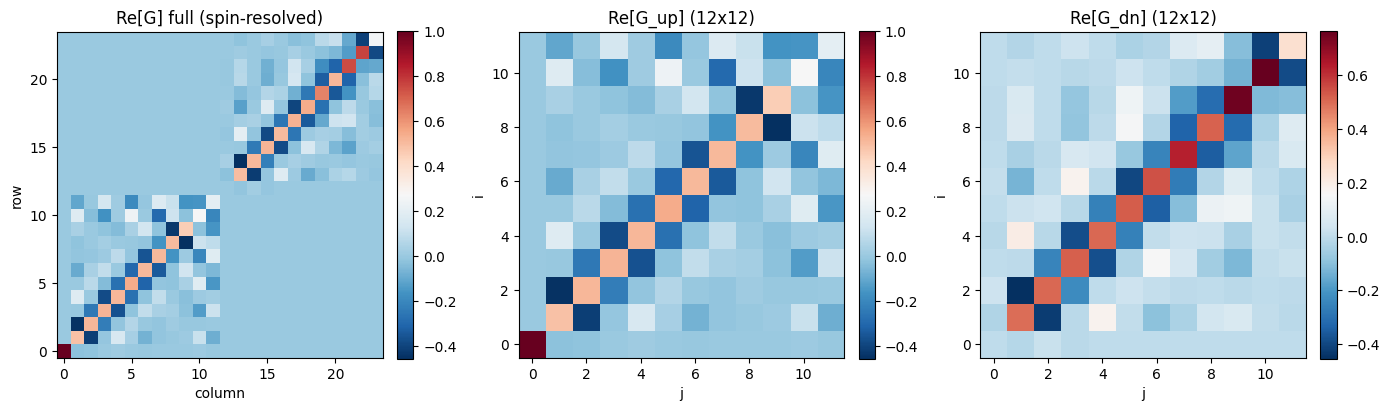

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from netket.operator.fermion import create as cdag
from netket.operator.fermion import destroy as c

# 选择用于观测的变分态（优先 BF）
def _pick_vstate_for_g():
    for name in ("vstate_bf", "vstate_nj", "vstate_slater"):
        if name in globals():
            return name, globals()[name]
    raise RuntimeError("未找到可用 variational state，请先运行第 18/20/22 个代码块之一。")

state_name, vstate_obs = _pick_vstate_for_g()
print(f"Use variational state: {state_name}")

# 自旋分辨维度：n_ob = 2 * n_orbitals
n_orb = hi.n_orbitals
n_ob = hi.n_orbitals * hi.n_spin_subsectors

# 采样参数（可按内存调小）
sample_n = 1024
sample_discard = 16

# 暂存并临时覆盖采样设置
old_n_samples = int(vstate_obs.n_samples)
old_n_discard = int(vstate_obs.n_discard_per_chain)
vstate_obs.n_samples = sample_n
vstate_obs.n_discard_per_chain = sample_discard

# 直接采样一次：后续 local_estimators 复用这批样本
_ = vstate_obs.sample(n_samples=sample_n, n_discard_per_chain=sample_discard)

# 构造自旋分辨格林函数矩阵
G = np.zeros((n_ob, n_ob), dtype=np.complex128)

# 仅同自旋块非零（当前哈密顿量无自旋翻转）
spin_specs = ((+1, 0), (-1, n_orb))  # (sz, block_offset)
for sz, off in spin_specs:
    for i in range(n_orb):
        for j in range(n_orb):
            op_ij = cdag(hi, i, sz=sz) @ c(hi, j, sz=sz)
            loc_ij = np.asarray(vstate_obs.local_estimators(op_ij)).reshape(-1)
            G[off + i, off + j] = np.mean(loc_ij)

# 恢复原采样设置
vstate_obs.n_samples = old_n_samples
vstate_obs.n_discard_per_chain = old_n_discard

# 分块检查
G_up = G[:n_orb, :n_orb]
G_dn = G[n_orb:, n_orb:]
G_updn = G[:n_orb, n_orb:]
G_dnup = G[n_orb:, :n_orb]

print("G shape =", G.shape)
print("expected shape =", (n_ob, n_ob))
print("||G_up||_F =", np.linalg.norm(G_up))
print("||G_dn||_F =", np.linalg.norm(G_dn))
print("||G_updn||_F =", np.linalg.norm(G_updn))
print("||G_dnup||_F =", np.linalg.norm(G_dnup))
print("max |G - G^†| =", np.max(np.abs(G - G.conj().T)))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

im0 = axes[0].imshow(G.real, origin="lower", cmap="RdBu_r")
axes[0].set_title("Re[G] full (spin-resolved)")
axes[0].set_xlabel("column")
axes[0].set_ylabel("row")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(G_up.real, origin="lower", cmap="RdBu_r")
axes[1].set_title(f"Re[G_up] ({n_orb}x{n_orb})")
axes[1].set_xlabel("j")
axes[1].set_ylabel("i")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(G_dn.real, origin="lower", cmap="RdBu_r")
axes[2].set_title(f"Re[G_dn] ({n_orb}x{n_orb})")
axes[2].set_xlabel("j")
axes[2].set_ylabel("i")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

G_matrix = G

### 8.1 `obs` 数量对运行效率的影响（基准测试）

本测试用于评估：在 `run(..., obs=...)` 中加入不同数量的格林函数观测量时，每个迭代步的平均耗时如何变化。

- 观测量池使用单自旋（`sz=+1`）的 $G_{ij}=\langle c^\dagger_{i\uparrow}c_{j\uparrow}\rangle$；
- 对当前 `n_orb=12`，全元素数为 $12\times12=144$；
- 测试点：`1,2,4,8,16,32,64,128,144`；
- 指标：`time_per_iter = elapsed / n_iter_bench`。

Benchmark driver = BF
n_orb = 12, full_count = 144


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

obs=  1 | time/iter=8.033727s ± 0.007569s


  0%|          | 0/5 [00:00<?, ?it/s]

...

  0%|          | 0/5 [00:00<?, ?it/s]

obs=128 | time/iter=15.322715s ± 0.079858s


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

obs=144 | time/iter=16.001079s ± 0.485863s


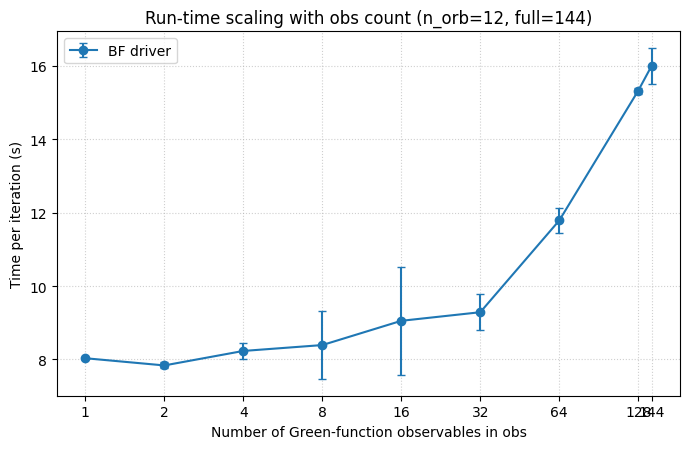

{'obs_count': array([  1,   2,   4,   8,  16,  32,  64, 128, 144]),
 'time_per_iter_mean_s': array([ 8.03372695,  7.83754849,  8.23215594,  8.3922456 ,  9.05306802,
         9.28707077, 11.78666039, 15.32271462, 16.00107862]),
 'time_per_iter_std_s': array([0.00756855, 0.08126309, 0.2256504 , 0.92864652, 1.47097234,
        0.48507485, 0.32879829, 0.07985798, 0.48586272])}

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd

# ===== 可调参数 =====
n_iter_bench = 5
n_repeat = 2
show_progress = True

# 选择用于 benchmark 的 driver（优先 BF）
def _pick_driver_for_bench():
    if "gs_bf" in globals() and "vstate_bf" in globals():
        return "BF", gs_bf, vstate_bf
    if "gs_nj" in globals() and "vstate_nj" in globals():
        return "NJ", gs_nj, vstate_nj
    if "gs_slater" in globals() and "vstate_slater" in globals():
        return "Slater", gs_slater, vstate_slater
    raise RuntimeError("未找到可用 driver/vstate，请先运行第 18/20/22 个代码块之一。")

state_tag, driver_bench, vstate_bench = _pick_driver_for_bench()
print(f"Benchmark driver = {state_tag}")

n_orb = hi.n_orbitals
full_count = n_orb * n_orb
print(f"n_orb = {n_orb}, full_count = {full_count}")

# 构造并转换单自旋（up）格林函数观测量池，共 n_orb*n_orb 个
# 这样可避免 Fixed-fermion Hilbert 上的 FermionOperator2nd 警告并提升效率
op_pool = []
for i in range(n_orb):
    for j in range(n_orb):
        key = f"Gup_{i}_{j}"
        op_raw = cdag(hi, i, sz=+1) @ c(hi, j, sz=+1)
        op_conv = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(op_raw)
        op_pool.append((key, op_conv))

counts = [1, 2, 4, 8, 16, 32, 64, 128, 144]
counts = [k for k in counts if k <= full_count]
if full_count not in counts:
    counts.append(full_count)
counts = sorted(set(counts))

old_n_samples = int(vstate_bench.n_samples)
old_n_discard = int(vstate_bench.n_discard_per_chain)
bench_n_samples = min(old_n_samples, 2**13)
vstate_bench.n_samples = bench_n_samples
vstate_bench.n_discard_per_chain = old_n_discard

warm_obs = {op_pool[0][0]: op_pool[0][1]}
_ = driver_bench.run(n_iter=1, out=nk.logging.RuntimeLog(), obs=warm_obs, show_progress=False)

records = []
try:
    for k in counts:
        obs_k = {name: op for name, op in op_pool[:k]}

        per_iter_list = []
        for rep in range(n_repeat):
            log_k = nk.logging.RuntimeLog()
            t0 = time.perf_counter()
            driver_bench.run(
                n_iter=n_iter_bench,
                out=log_k,
                obs=obs_k,
                show_progress=show_progress,
            )
            t1 = time.perf_counter()
            per_iter_list.append((t1 - t0) / n_iter_bench)

        mean_t = float(np.mean(per_iter_list))
        std_t = float(np.std(per_iter_list))
        records.append((k, mean_t, std_t))
        print(f"obs={k:3d} | time/iter={mean_t:.6f}s ± {std_t:.6f}s")

finally:
    vstate_bench.n_samples = old_n_samples
    vstate_bench.n_discard_per_chain = old_n_discard

records = np.array(records, dtype=float)
obs_counts = records[:, 0]
time_mean = records[:, 1]
time_std = records[:, 2]

plt.figure(figsize=(7.0, 4.6))
plt.errorbar(obs_counts, time_mean, yerr=time_std, marker="o", capsize=3, label=f"{state_tag} driver")
plt.xscale("log", base=2)
plt.xticks(obs_counts, [str(int(x)) for x in obs_counts], rotation=0)
plt.xlabel("Number of Green-function observables in obs")
plt.ylabel("Time per iteration (s)")
plt.title(f"Run-time scaling with obs count (n_orb={n_orb}, full={full_count})")
plt.grid(True, which="both", ls=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

bench_table = {
    "obs_count": obs_counts.astype(int),
    "time_per_iter_mean_s": time_mean,
    "time_per_iter_std_s": time_std,
}
bench_table

In [1]:
import numpy as np
import netket as nk

from netket.graph.common_lattices import Chain
from netket.operator.fermion import destroy as c
from netket.operator.fermion import create as cdag
from netket.operator.fermion import number as nc

print('NetKet version:', nk.__version__)

∣NK⟩ Tip: You can use flax.linen, flax.nnx and equinox to define neural networks.

NetKet version: 3.21.1.dev13+gbf43effcb.d20260217


## 1) 定义链与 Hilbert 空间

In [2]:
L = 11  # 导带链长度（不含杂质）
chain = Chain(L, pbc=False)
N = chain.n_nodes   # 格点数量，后续会被应用为神经网络的优化参数数量

impurity_site = 0
conduction_offset = 1  # 导带链局部索引 i -> 全局站点 i+1
n_orbitals = L + 1  # 1 个杂质轨道 + L 个导带轨道

if n_orbitals % 2 != 0:
    raise ValueError("n_orbitals 必须为偶数，才能设置 N_up = N_dn = n_orbitals/2")

N_up = n_orbitals // 2
N_dn = n_orbitals // 2

# 在这里直接限制 Hilbert 空间粒子数
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals, s=1 / 2, n_fermions_per_spin=(N_up, N_dn)
 )

print('chain nodes =', chain.n_nodes, ', chain edges =', chain.n_edges)
print('n_orbitals =', n_orbitals)
print('fixed particles (N_up, N_dn) =', (N_up, N_dn))

chain nodes = 11 , chain edges = 10
n_orbitals = 12
fixed particles (N_up, N_dn) = (6, 6)


## 2) 参数（单独一段，便于调试）

In [3]:
U = 4.0

# Wilson chain 参数
D = 1.0
Lambda = 2.0
V = 0.15 * D

# t_j, j = 1, 2, ..., L-1（对应哈密顿量里的 ti[i-1]）
j = np.arange(1, L, dtype=float)
ti = (
    ((1.0 + Lambda**-1.0) * (1.0 - Lambda**(-j - 1.0)))
    / (
        2.0
        * np.sqrt(1.0 - Lambda**(-2.0 * j - 1.0))
        * np.sqrt(1.0 - Lambda**(-2.0 * j - 3.0))
    )
    * Lambda**(-j / 2.0)
    * D
)

## 3) 构造 SIAM 哈密顿量

In [4]:
H = 0.0

# 杂质上的库仑相互作用: U (n_d↑ - 1/2)(n_d↓ - 1/2)
n_d_up = nc(hi, impurity_site, sz=+1)
n_d_dn = nc(hi, impurity_site, sz=-1)
H += U * (n_d_up - 0.5) @ (n_d_dn - 0.5)

# 杂质-导带首站点混成: V Σσ (d†σ c0σ + c0†σ dσ)
c0_site = conduction_offset
for sz in (+1, -1):
    H += V * (cdag(hi, impurity_site, sz=sz) @ c(hi, c0_site, sz=sz))
    H += V * (cdag(hi, c0_site, sz=sz) @ c(hi, impurity_site, sz=sz))

# 导带链 hopping: Σσ Σ_i t_i (c†_{iσ} c_{i-1,σ} + h.c.)
# 使用 Chain(L) 的边来确定一维最近邻，局部索引 (0..L-1) 需要偏移到全局站点 (1..L)。
for i_local, j_local in chain.edges():
    left_local, right_local = sorted((i_local, j_local))
    t_bond = ti[left_local]

    left_site = left_local + conduction_offset
    right_site = right_local + conduction_offset

    for sz in (+1, -1):
        H += t_bond * (cdag(hi, right_site, sz=sz) @ c(hi, left_site, sz=sz))
        H += t_bond * (cdag(hi, left_site, sz=sz) @ c(hi, right_site, sz=sz))

H

FermionOperator2ndJax(hilbert=SpinOrbitalFermions(n_orbitals=12, s=1/2, n_fermions=12, n_fermions_per_spin=(6, 6)), n_operators=48, dtype=float64)

## 4) 简单检查

In [5]:
print('max_conn_size =', H.max_conn_size)
print('ti length =', len(ti), '(expected L-1 =', L - 1, ')')

D:\Program Files\Python_lib\My_lib\Netket\netket\netket\operator\_fermion2nd\jax.py:557: UserWarning: 
Consider using `netket.experimental.operator.ParticleNumberAndSpinConservingFermioperator2nd` to reduce the number of connected elements and
considerably reduce the computational cost.
You can convert this operator by calling `netket.experimental.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd`.

  super()._setup(self)


max_conn_size = 45
ti length = 10 (expected L-1 = 10 )


## 5) 画图：10 个 site 的 SIAM 晶格（杂质单独着色）

下面将杂质 site（0）标成红色，导带 site（1..L）标成蓝色。

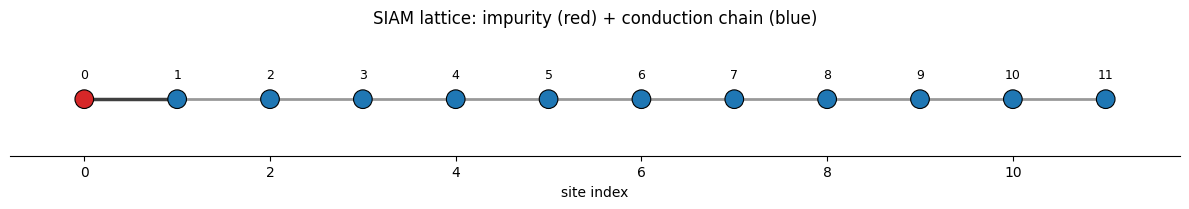

In [6]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(12, 2.2))

# 导带内部边（将 chain 的局部索引映射到全局站点 1..L）
for i_local, j_local in chain.edges():
    ax.plot(
        [i_local + conduction_offset, j_local + conduction_offset],
        [0, 0],
        color="0.6",
        lw=2,
        zorder=1,
    )

# 杂质-导带首站点混成边
ax.plot([impurity_site, c0_site], [0, 0], color="0.25", lw=2.5, zorder=2)

# 节点着色：杂质红色，其它导带蓝色
x = np.arange(n_orbitals)
y = np.zeros(n_orbitals)
node_colors = ["tab:red"] + ["tab:blue"] * L
ax.scatter(x, y, c=node_colors, s=180, edgecolors="black", linewidths=0.8, zorder=3)

for site in range(n_orbitals):
    ax.text(site, 0.08, str(site), ha="center", va="bottom", fontsize=9)

ax.set_yticks([])
ax.set_xlabel("site index")
ax.set_title("SIAM lattice: impurity (red) + conduction chain (blue)")
ax.set_xlim(-0.8, n_orbitals - 0.2)
ax.set_ylim(-0.25, 0.3)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

## 6) 严格对角化（ED）

参照 `lattice-fermions.ipynb` 的思路：先把哈密顿量转为稀疏矩阵，再用 `scipy.sparse.linalg.eigsh` 求低能本征值。

注意：对 10 个 site 的自旋费米子，若不固定粒子数，Hilbert 空间仍可能较大。这里在固定粒子数扇区做严格对角化。

In [7]:
from math import comb
from scipy.sparse.linalg import eigsh
from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd

# 直接复用第 3 段已构造好的 H（其 Hilbert 空间已固定粒子数）
N_up_ed, N_dn_ed = N_up, N_dn
sector_dim = comb(n_orbitals, N_up_ed) * comb(n_orbitals, N_dn_ed)
max_dim_for_sparse_ed = 2000000  # 经验阈值，可按机器内存调整

print("ED sector (N_up, N_dn) =", (N_up_ed, N_dn_ed))
print("Estimated Hilbert dimension =", sector_dim)

if sector_dim > max_dim_for_sparse_ed:
    print(
        "[Skip ED] 该扇区维度过大，不执行 to_sparse()/eigsh 以避免内存溢出。"
    )
    print("建议: 减小粒子数（如 1,1 或 2,2）后再做严格对角化。")
else:
    H_ed = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(H)
    sp_h = H_ed.to_sparse()
    eig_vals, eig_vecs = eigsh(sp_h, k=4, which="SA")
    eig_vals = np.sort(np.real(eig_vals))

    print("Hilbert dimension in this sector =", sp_h.shape[0])
    print("Exact ground-state energy E0 =", eig_vals[0])
    print("Lowest 4 eigenvalues =", eig_vals)

ED sector (N_up, N_dn) = (6, 6)
Estimated Hilbert dimension = 853776
Hilbert dimension in this sector = 853776
Exact ground-state energy E0 = -3.1718488273452383
Lowest 4 eigenvalues = [-3.17184883 -3.17083428 -3.14127319 -3.14122398]


## 7) 变分波函数优化（对齐 lattice-fermions 教程的完整流程）

下面依次实现并优化三类变分波函数：

1. Slater 行列式
2. Neural Jastrow-Slater
3. Neural Backflow

说明：以下文字推导与代码结构参考 tutorial，但已按 SIAM（含自旋）场景改写为等价表述。

In [8]:
import jax
import jax.numpy as jnp
import flax.linen as nn
from functools import partial

from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd

# ========= Reproducibility seeds =========
SEED_MODEL_SLATER = 11
SEED_SAMPLER_SLATER = 101
SEED_MODEL_NJ = 22
SEED_SAMPLER_NJ = 202
SEED_MODEL_BF = 33
SEED_SAMPLER_BF = 303

# 给采样器构造“空间轨道图”：杂质-首导带 + 导带链最近邻
sampler_edges = [(impurity_site, c0_site)]
sampler_edges += [
    (min(i, j) + conduction_offset, max(i, j) + conduction_offset)
    for (i, j) in chain.edges()
 ]
graph_sampler = nk.graph.Graph(edges=sampler_edges, n_nodes=n_orbitals)

# 如果第 6 段已执行，则直接复用基准能量；否则临时算一次（用于后续误差对比）
if "eig_vals" in globals():
    E_gs = float(np.sort(np.real(eig_vals))[0])
else:
    H_ref = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(H)
    from scipy.sparse.linalg import eigsh
    ref_vals, _ = eigsh(H_ref.to_sparse(), k=2, which="SA")
    E_gs = float(np.sort(np.real(ref_vals))[0])

print("reference E_gs =", E_gs)
print("sampler graph nodes/edges =", graph_sampler.n_nodes, graph_sampler.n_edges)
print(
    "seeds:",
    (SEED_MODEL_SLATER, SEED_SAMPLER_SLATER, SEED_MODEL_NJ, SEED_SAMPLER_NJ, SEED_MODEL_BF, SEED_SAMPLER_BF),
)

reference E_gs = -3.1718488273452383
sampler graph nodes/edges = 12 11
seeds: (11, 101, 22, 202, 33, 303)


### 7.1 Slater 行列式

对固定粒子数费米体系，Slater 态可写为占据轨道子矩阵行列式。优化目标是最小化
$ E(\theta)=\langle\Psi_\theta|H|\Psi_\theta\rangle/\langle\Psi_\theta|\Psi_\theta\rangle $。

这里采用与教程一致的 VMC+SR 框架。

In [9]:
class LogSlaterDeterminant(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    @nn.compact
    def __call__(self, n):
        # 直接复用 NetKet 内建 Slater2nd（限制在固定粒子数子空间）
        return nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=True, param_dtype=float
        )(n)

model_slater = LogSlaterDeterminant(hi)
sa_slater = nk.sampler.MetropolisFermionHop(
    hi, graph=graph_sampler, spin_symmetric=True
 )
vstate_slater = nk.vqs.MCState(
    sa_slater,
    model_slater,
    n_samples=2**13,
    n_discard_per_chain=16,
    seed=SEED_MODEL_SLATER,
    sampler_seed=SEED_SAMPLER_SLATER,
 )

op_slater = nk.optimizer.Sgd(learning_rate=0.05)
gs_slater = nk.driver.VMC_SR(
    H, op_slater, variational_state=vstate_slater, diag_shift=0.05, mode="real"
 )

slater_log = nk.logging.RuntimeLog()
gs_slater.run(n_iter=300, out=slater_log)

E_slater = vstate_slater.expect(H)
err_slater = abs((E_slater.mean - E_gs) / E_gs)
print(f"Slater optimized energy: {E_slater}")
print(f"Slater relative error  : {err_slater}")

Automatic SR implementation choice:  QGT


  0%|          | 0/300 [00:00<?, ?it/s]

Slater optimized energy: -2.280+0.000j ± 0.014 [σ²=1.0e+00, R̂=1.002]
Slater relative error  : 0.2812267457252616


### 7.2 Neural Jastrow-Slater

在 Slater 振幅外再乘一个神经网络 Jastrow 因子：
$ \log\Psi(\mathbf{n}) = \log\Phi_{\mathrm{Slater}}(\mathbf{n}) + J_\theta(\mathbf{n}) $.

它主要增强相关性描述（尤其是振幅模值部分）。

In [10]:
class LogNeuralJastrowSlater(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = N

    @nn.compact
    def __call__(self, n):
        log_slater = nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=True, param_dtype=float
        )(n)

        x = n.astype(jnp.float32)
        j = nn.Dense(self.hidden_units)(x)
        j = jax.nn.tanh(j)
        j = nn.Dense(1)(j).squeeze(-1)
        return log_slater + j

model_nj = LogNeuralJastrowSlater(hi, hidden_units=max(32, 2 * n_orbitals))
sa_nj = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
vstate_nj = nk.vqs.MCState(
    sa_nj,
    model_nj,
    n_samples=2**13,
    n_discard_per_chain=16,
    seed=SEED_MODEL_NJ,
    sampler_seed=SEED_SAMPLER_NJ,
 )
nj_p = vstate_nj.n_parameters
print(f" [NJ] Params: {nj_p}")

op_nj = nk.optimizer.Sgd(learning_rate=0.05)
gs_nj = nk.driver.VMC_SR(
    H, op_nj, variational_state=vstate_nj, diag_shift=0.05, mode="real"
 )

nj_log = nk.logging.RuntimeLog()
gs_nj.run(n_iter=300, out=nj_log)

E_nj = vstate_nj.expect(H)
err_nj = abs((E_nj.mean - E_gs) / E_gs)
print(f"Neural Jastrow-Slater optimized energy: {E_nj}")
print(f"Neural Jastrow-Slater relative error  : {err_nj}")

 [NJ] Params: 905
Automatic SR implementation choice:  QGT


  0%|          | 0/300 [00:00<?, ?it/s]

Neural Jastrow-Slater optimized energy: -3.1446+0.0000j ± 0.0012 [σ²=7.7e-03, R̂=1.003]
Neural Jastrow-Slater relative error  : 0.008583703855451019


### 7.3 Neural Backflow

Backflow 的思想是把 Slater 轨道矩阵推广为构型依赖：
$ M^{\mathrm{bf}}(\mathbf{n})=M+F_\theta(\mathbf{n})$ .

下面给出与教程同类型的“加性 backflow”实现：神经网络输出与轨道矩阵同形状的修正项。

In [11]:
class LogNeuralBackflow(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = N

    @nn.compact
    def __call__(self, n):
        n_orb = self.hilbert.n_orbitals
        n_spin = self.hilbert.n_spin_subsectors
        nfs = self.hilbert.n_fermions_per_spin[0]

        # 限制型 HF 基轨道（所有自旋扇区共享）
        M = self.param(
            "M",
            nn.initializers.lecun_normal(),
            (n_orb, nfs),
            float,
        )

        # Backflow 网络：输出 (n_spin, n_orb, nfs)
        x = n.astype(jnp.float32)
        F = nn.Dense(self.hidden_units)(x)
        F = jax.nn.tanh(F)
        F = nn.Dense(n_spin * n_orb * nfs)(F)
        F = F.reshape(F.shape[:-1] + (n_spin, n_orb, nfs))

        @partial(jnp.vectorize, signature="(m),(s,o,f)->()")
        def log_bf(n_one, F_one):
            R = n_one.nonzero(size=self.hilbert.n_fermions)[0]
            log_det_sum = 0.0 + 0.0j
            i_start = 0

            for i, nf_i in enumerate(self.hilbert.n_fermions_per_spin):
                if nf_i == 0:
                    continue
                R_i = R[i_start : i_start + nf_i] - i * n_orb
                A_i = (M + F_one[i])[R_i]
                log_det_sum = log_det_sum + nk.jax.logdet_cmplx(A_i)
                i_start += nf_i

            return log_det_sum

        return log_bf(n, F)

model_bf = LogNeuralBackflow(hi, hidden_units=max(32, 2 * n_orbitals))
sa_bf = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
vstate_bf = nk.vqs.MCState(
    sa_bf,
    model_bf,
    n_samples=2**13,
    n_discard_per_chain=16,
    seed=SEED_MODEL_BF,
    sampler_seed=SEED_SAMPLER_BF,
 )
bf_p = vstate_bf.n_parameters
print(f" [BF] Params: {bf_p}")

op_bf = nk.optimizer.Sgd(learning_rate=0.05)
gs_bf = nk.driver.VMC_SR(
    H, op_bf, variational_state=vstate_bf, diag_shift=0.05, mode="real"
 )

bf_log = nk.logging.RuntimeLog()
gs_bf.run(n_iter=300, out=bf_log)

E_bf = vstate_bf.expect(H)
err_bf = abs((E_bf.mean - E_gs) / E_gs)
print(f"Neural Backflow optimized energy: {E_bf}")
print(f"Neural Backflow relative error  : {err_bf}")

 [BF] Params: 5624
Automatic SR implementation choice:  QGT


  0%|          | 0/300 [00:00<?, ?it/s]

Neural Backflow optimized energy: -3.11502+0.00000j ± 0.00076 [σ²=3.1e-03, R̂=1.003]
Neural Backflow relative error  : 0.017917026676281263


### 7.4 结果汇总作图

和教程相同，把三种 ansatz 的优化能量曲线放在一张图中，并与 ED 基准能量比较。

### 扫描说明

- **用途**：扫描不同 `hidden_units` 下的 Neural Jastrow 与 Neural Backflow 的最终能量，并在同一张图中比较。
- **可调参数**：在代码单元中修改 `hidden_list`、`n_iter_scan`、`n_samples_scan` 以控制精度与运行时间。
- **运行提示**：每个配置会进行简化的 VMC 优化，可能耗时较长；建议先用较小的 `hidden_list` 和 `n_iter_scan` 进行快速试验。
- **输出**：绘制 `Energy vs hidden units` 曲线，并标注 ED 精确能量与 Slater 参考线（若可用）。


In [12]:
# import netket as nk
# import numpy as np

# # 扫描不同 hidden units 下的 Neural Jastrow (NJ) 与 Neural Backflow (BF)
# hidden_list = [8, 16, 32, 64, 128]
# n_iter_scan = 150
# n_samples_scan = 2**12

# # 扩展 results 字典，增加存储历史数据和参数量的键
# results = {
#     'hidden': [], 
#     'nj_energy': [], 
#     'bf_energy': [],
#     'nj_histories': [], # 存储 NJ 每一步的能量均值
#     'bf_histories': [], # 存储 BF 每一步的能量均值
#     'nj_params': [],    # 存储 NJ 参数量
#     'bf_params': []     # 存储 BF 参数量
# }

# for h in hidden_list:
#     print(f'== hidden_units = {h} ==')
    
#     # --- Neural Jastrow ---
#     try:
#         model_nj_scan = LogNeuralJastrowSlater(hi, hidden_units=h)
#         sa_nj_scan = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
#         vstate_nj_scan = nk.vqs.MCState(sa_nj_scan, model_nj_scan, n_samples=n_samples_scan, n_discard_per_chain=16, seed=SEED_MODEL_NJ + h, sampler_seed=SEED_SAMPLER_NJ + h)
        
#         # 记录参数量
#         nj_p = vstate_nj_scan.n_parameters
#         results['nj_params'].append(nj_p)
#         print(f" [NJ] Params: {nj_p}")

#         opt_nj = nk.optimizer.Sgd(learning_rate=0.05)
#         # 创建 Logger
#         log_nj = nk.logging.RuntimeLog()
#         driver_nj = nk.driver.VMC_SR(H, opt_nj, variational_state=vstate_nj_scan, diag_shift=0.05, mode='real')
        
#         # 传入 out=log_nj 来记录历史
#         driver_nj.run(n_iter=n_iter_scan, out=log_nj)
        
#         # 提取历史能量均值
#         results['nj_histories'].append(log_nj.data['Energy']['Mean'])
        
#         E_nj_scan = vstate_nj_scan.expect(H)
#         nj_val = float(E_nj_scan.mean.real)
#     except Exception as e:
#         print('NJ scan failed for h=', h, '->', e)
#         nj_val = float('nan')
#         results['nj_histories'].append([])
#         results['nj_params'].append(0)

#     # --- Neural Backflow ---
#     try:
#         model_bf_scan = LogNeuralBackflow(hi, hidden_units=h)
#         sa_bf_scan = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
#         vstate_bf_scan = nk.vqs.MCState(sa_bf_scan, model_bf_scan, n_samples=n_samples_scan, n_discard_per_chain=16, seed=SEED_MODEL_BF + h, sampler_seed=SEED_SAMPLER_BF + h)
        
#         # 记录参数量
#         bf_p = vstate_bf_scan.n_parameters
#         results['bf_params'].append(bf_p)
#         print(f" [BF] Params: {bf_p}")

#         opt_bf = nk.optimizer.Sgd(learning_rate=0.05)
#         # 创建 Logger
#         log_bf = nk.logging.RuntimeLog()
#         driver_bf = nk.driver.VMC_SR(H, opt_bf, variational_state=vstate_bf_scan, diag_shift=0.05, mode='real')
        
#         # 传入 out=log_bf 来记录历史
#         driver_bf.run(n_iter=n_iter_scan, out=log_bf)
        
#         # 提取历史能量均值
#         results['bf_histories'].append(log_bf.data['Energy']['Mean'])
        
#         E_bf_scan = vstate_bf_scan.expect(H)
#         bf_val = float(E_bf_scan.mean.real)
#     except Exception as e:
#         print('BF scan failed for h=', h, '->', e)
#         bf_val = float('nan')
#         results['bf_histories'].append([])
#         results['bf_params'].append(0)

#     results['hidden'].append(h)
#     results['nj_energy'].append(nj_val)
#     results['bf_energy'].append(bf_val)


In [13]:
# # 绘图：在同一张图中显示 NJ 与 BF 的能量随 hidden units 的变化，并标注 ED 与 Slater 基线
# from matplotlib import pyplot as plt
# plt.figure(figsize=(7,4))
# plt.plot(results['hidden'], results['nj_energy'], '-o', label='Neural Jastrow')
# plt.plot(results['hidden'], results['bf_energy'], '-s', label='Neural Backflow')
# plt.hlines(E_gs, xmin=min(results['hidden']), xmax=max(results['hidden']), colors='k', linestyles='--', label='ED exact')
# # 如果 Slater 能量存在，则绘制为参考线（可能之前已计算）
# try:
#     slater_val = float(E_slater.mean.real)
#     plt.hlines(slater_val, xmin=min(results['hidden']), xmax=max(results['hidden']), colors='gray', linestyles=':', label='Slater')
# except Exception:
#     pass

# plt.xscale('log', base=2)
# plt.xlabel('hidden units')
# plt.ylabel('Energy')
# plt.title('Energy vs hidden units: Neural Jastrow vs Neural Backflow')
# plt.legend()
# plt.grid(True)
# plt.show()

In [14]:
# import matplotlib.pyplot as plt
# import numpy as np

# # 设置画布
# plt.figure(figsize=(12, 7))

# # 使用 colormap 生成一组颜色，确保不同 hidden units 之间有区分度
# colors = plt.cm.viridis(np.linspace(0, 0.9, len(hidden_list)))

# # 假设你在循环中已经将历史数据存入 results['nj_histories'] = [array1, array2, ...]
# # 如果你使用的是 NetKet 的 JsonLog 或 RuntimeLog，数据通常在 logger.data['Energy']['Mean']
# for i, h in enumerate(hidden_list):
#     # 绘制 Neural Jastrow 的收敛曲线 (虚线)
#     if 'nj_histories' in results and i < len(results['nj_histories']):
#         y_nj = results['nj_histories'][i]
#         plt.plot(y_nj, color=colors[i], linestyle='--', alpha=0.6, 
#                  label=f'NJ (h={h})')
    
#     # 绘制 Neural Backflow 的收敛曲线 (实线)
#     if 'bf_histories' in results and i < len(results['bf_histories']):
#         y_bf = results['bf_histories'][i]
#         plt.plot(y_bf, color=colors[i], linestyle='-', linewidth=1.5,
#                  label=f'BF (h={h})')

# # 绘制 ED 精确能量参考线
# if 'E_gs' in locals():
#     plt.axhline(y=E_gs, color='red', linestyle=':', label='Exact (ED)', alpha=0.8, zorder=0)

# # 图表修饰
# plt.title('Energy Convergence History: NJ vs BF', fontsize=14)
# plt.xlabel('Iteration', fontsize=12)
# plt.ylabel('Energy', fontsize=12)

# # 将图例放在右侧，避免遮挡收敛曲线
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, fontsize=9)

# plt.grid(True, which='both', linestyle=':', alpha=0.5)
# plt.tight_layout()
# plt.show()


In [15]:
# import numpy as np

# # 遍历 hidden_list，将每个配置的收敛历史保存为独立的 txt 文件
# for i, h in enumerate(results['hidden']):
#     # --- 保存 Neural Jastrow (NJ) 历史 ---
#     nj_history = results['nj_histories'][i]
#     if len(nj_history) > 0:
#         filename_nj = f"energy_history_nj_h{h}.txt"
#         # 构造数据：第一列是迭代步数，第二列是能量均值
#         # 注意：使用 .real 确保保存的是实部
#         iters = np.arange(len(nj_history))
#         data_nj = np.column_stack((iters, np.array(nj_history).real))
        
#         # 保存文件，fmt 指定格式（整数步数，10位小数能量）
#         np.savetxt(filename_nj, data_nj, fmt='%d %.10f', 
#                    header=f"NJ hidden_units={h}\nIteration Energy_Mean")
#         print(f"已保存: {filename_nj}")

#     # --- 保存 Neural Backflow (BF) 历史 ---
#     bf_history = results['bf_histories'][i]
#     if len(bf_history) > 0:
#         filename_bf = f"energy_history_bf_h{h}.txt"
#         iters = np.arange(len(bf_history))
#         data_bf = np.column_stack((iters, np.array(bf_history).real))
        
#         np.savetxt(filename_bf, data_bf, fmt='%d %.10f', 
#                    header=f"BF hidden_units={h}\nIteration Energy_Mean")
#         print(f"已保存: {filename_bf}")

# # --- 额外步骤：保存一个汇总所有 hidden units 最终能量的摘要文件 ---
# summary_file = "summary_results.txt"
# # 准备汇总数据
# summary_table = np.column_stack((
#     results['hidden'],
#     results['nj_params'],
#     results['nj_energy'],
#     results['bf_params'],
#     results['bf_energy']
# ))

# np.savetxt(summary_file, summary_table, fmt='%d %d %.10f %d %.10f',
#            header="Hidden_Units NJ_Params NJ_Energy BF_Params BF_Energy")
# print(f"\n所有配置的最终结果已汇总至: {summary_file}")


C:\Users\yufei\AppData\Local\Temp\ipykernel_25288\3704902203.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


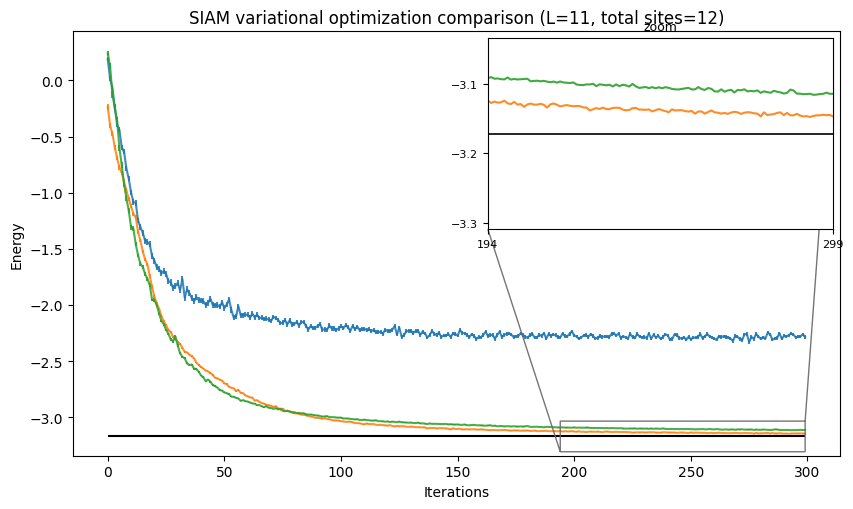

In [19]:
logged_data = (slater_log.data, nj_log.data, bf_log.data)
labels = ("Slater", "Neural Jastrow", "Neural Backflow")

from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(figsize=(8.6, 5.2))
for data, label in zip(logged_data, labels):
    ax.errorbar(
        data["Energy"].iters,
        data["Energy"].Mean.real,
        yerr=data["Energy"].Sigma,
        label=label,
        alpha=0.85,
    )

iters_max = max(data["Energy"].iters[-1] for data in logged_data)
ax.hlines([E_gs], xmin=0, xmax=iters_max, color="black", label="ED Exact")

ax.set_xlabel("Iterations")
ax.set_ylabel("Energy")
ax.legend()
ax.set_title(f"SIAM variational optimization comparison (L={L}, total sites={n_orbitals})")

# inset: 放大末段迭代与接近 E_gs 的能量窗口
axins = inset_axes(ax, width="45%", height="45%", loc="upper right")
for data, _label in zip(logged_data, labels):
    axins.plot(data["Energy"].iters, data["Energy"].Mean.real, alpha=0.9)
axins.hlines([E_gs], xmin=0, xmax=iters_max, color="black", linewidth=1.2)

# 自动设置放大窗口（后 35% 迭代 + 更窄的 E_gs 邻域）
x1 = int(0.65 * iters_max)
x2 = int(iters_max)
all_means = np.concatenate([np.asarray(d["Energy"].Mean.real) for d in logged_data])
y_center = E_gs
y_span = max(1e-6, 0.04 * np.max(np.abs(all_means - y_center)))
axins.set_xlim(x1, x2)
axins.set_ylim(y_center - y_span, y_center + y_span)
axins.set_xticks([x1, x2])

# 打开并设置 inset 的 y 轴刻度
axins.yaxis.set_major_locator(MaxNLocator(nbins=3))
axins.tick_params(axis="y", labelsize=8)
axins.tick_params(axis="x", labelsize=8)
axins.set_title("zoom", fontsize=9)

# 使用 matplotlib 原生接口标注放大区域，连线更规整
ax.indicate_inset_zoom(axins, edgecolor="0.4", alpha=0.9)

plt.tight_layout()
plt.show()

## 8) 单体格林函数矩阵（自旋分辨）

这里采用自旋分辨定义：

$$
G_{(i,\sigma),(j,\sigma')}=\langle c^{\dagger}_{i\sigma}c_{j\sigma'}\rangle
$$

在当前 Hamiltonian 下无自旋翻转项，因此矩阵应呈块对角结构：

- 左上角 $N_{orb}\times N_{orb}$：自旋上块；
- 右下角 $N_{orb}\times N_{orb}$：自旋下块；
- 两个非对角自旋块应接近 0。

因此总矩阵维度是
$$
n_{ob}=2N_{orb},\quad G\in\mathbb{C}^{n_{ob}\times n_{ob}}.
$$
对你当前 $N_{orb}=12$，即 $G$ 为 $24\times24$。

Use variational state: vstate_bf


D:\Program Files\Python_lib\My_lib\Netket\netket\netket\operator\_fermion2nd\jax.py:557: UserWarning: 
Consider using `netket.experimental.operator.ParticleNumberAndSpinConservingFermioperator2nd` to reduce the number of connected elements and
considerably reduce the computational cost.
You can convert this operator by calling `netket.experimental.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd`.

  super()._setup(self)


G shape = (24, 24)
expected shape = (24, 24)
||G_up||_F = 2.4563617207113246
||G_dn||_F = 2.451397890408168
||G_updn||_F = 0.0
||G_dnup||_F = 0.0
max |G - G^†| = 0.09076778123472865


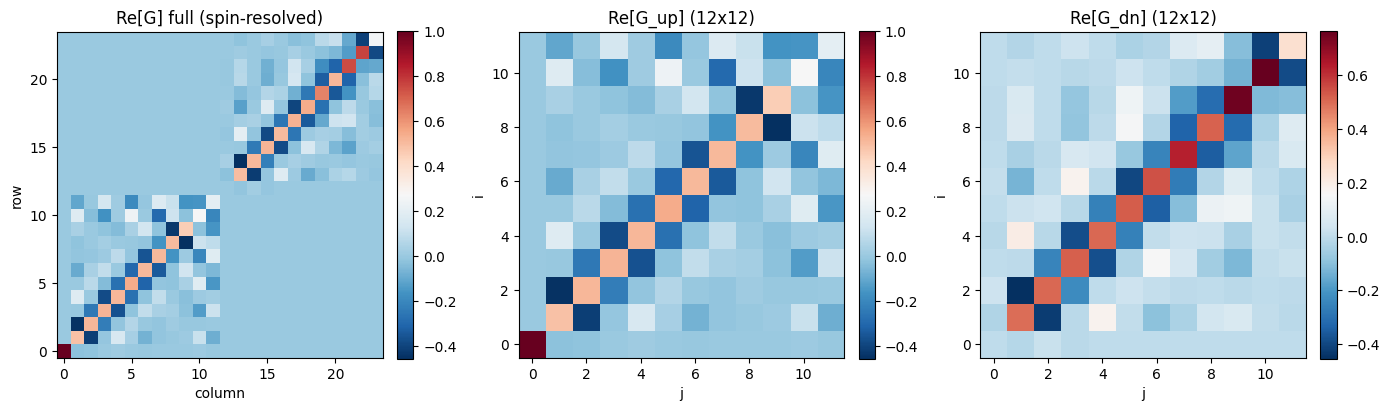

In [20]:
import numpy as np
from matplotlib import pyplot as plt
from netket.operator.fermion import create as cdag
from netket.operator.fermion import destroy as c

# 选择用于观测的变分态（优先 BF）
def _pick_vstate_for_g():
    for name in ("vstate_bf", "vstate_nj", "vstate_slater"):
        if name in globals():
            return name, globals()[name]
    raise RuntimeError("未找到可用 variational state，请先运行第 18/20/22 个代码块之一。")

state_name, vstate_obs = _pick_vstate_for_g()
print(f"Use variational state: {state_name}")

# 自旋分辨维度：n_ob = 2 * n_orbitals
n_orb = hi.n_orbitals
n_ob = hi.n_orbitals * hi.n_spin_subsectors

# 采样参数（可按内存调小）
sample_n = 1024
sample_discard = 16

# 暂存并临时覆盖采样设置
old_n_samples = int(vstate_obs.n_samples)
old_n_discard = int(vstate_obs.n_discard_per_chain)
vstate_obs.n_samples = sample_n
vstate_obs.n_discard_per_chain = sample_discard

# 直接采样一次：后续 local_estimators 复用这批样本
_ = vstate_obs.sample(n_samples=sample_n, n_discard_per_chain=sample_discard)

# 构造自旋分辨格林函数矩阵
G = np.zeros((n_ob, n_ob), dtype=np.complex128)

# 仅同自旋块非零（当前哈密顿量无自旋翻转）
spin_specs = ((+1, 0), (-1, n_orb))  # (sz, block_offset)
for sz, off in spin_specs:
    for i in range(n_orb):
        for j in range(n_orb):
            op_ij = cdag(hi, i, sz=sz) @ c(hi, j, sz=sz)
            loc_ij = np.asarray(vstate_obs.local_estimators(op_ij)).reshape(-1)
            G[off + i, off + j] = np.mean(loc_ij)

# 恢复原采样设置
vstate_obs.n_samples = old_n_samples
vstate_obs.n_discard_per_chain = old_n_discard

# 分块检查
G_up = G[:n_orb, :n_orb]
G_dn = G[n_orb:, n_orb:]
G_updn = G[:n_orb, n_orb:]
G_dnup = G[n_orb:, :n_orb]

print("G shape =", G.shape)
print("expected shape =", (n_ob, n_ob))
print("||G_up||_F =", np.linalg.norm(G_up))
print("||G_dn||_F =", np.linalg.norm(G_dn))
print("||G_updn||_F =", np.linalg.norm(G_updn))
print("||G_dnup||_F =", np.linalg.norm(G_dnup))
print("max |G - G^†| =", np.max(np.abs(G - G.conj().T)))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

im0 = axes[0].imshow(G.real, origin="lower", cmap="RdBu_r")
axes[0].set_title("Re[G] full (spin-resolved)")
axes[0].set_xlabel("column")
axes[0].set_ylabel("row")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(G_up.real, origin="lower", cmap="RdBu_r")
axes[1].set_title(f"Re[G_up] ({n_orb}x{n_orb})")
axes[1].set_xlabel("j")
axes[1].set_ylabel("i")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(G_dn.real, origin="lower", cmap="RdBu_r")
axes[2].set_title(f"Re[G_dn] ({n_orb}x{n_orb})")
axes[2].set_xlabel("j")
axes[2].set_ylabel("i")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

G_matrix = G

### 8.1 `obs` 数量对运行效率的影响（基准测试）

本测试用于评估：在 `run(..., obs=...)` 中加入不同数量的格林函数观测量时，每个迭代步的平均耗时如何变化。

- 观测量池使用单自旋（`sz=+1`）的 $G_{ij}=\langle c^\dagger_{i\uparrow}c_{j\uparrow}\rangle$；
- 对当前 `n_orb=12`，全元素数为 $12\times12=144$；
- 测试点：`1,2,4,8,16,32,64,128,144`；
- 指标：`time_per_iter = elapsed / n_iter_bench`。

Benchmark driver = BF
n_orb = 12, full_count = 144


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

obs=  1 | time/iter=8.033727s ± 0.007569s


  0%|          | 0/5 [00:00<?, ?it/s]

...

  0%|          | 0/5 [00:00<?, ?it/s]

obs=128 | time/iter=15.322715s ± 0.079858s


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

obs=144 | time/iter=16.001079s ± 0.485863s


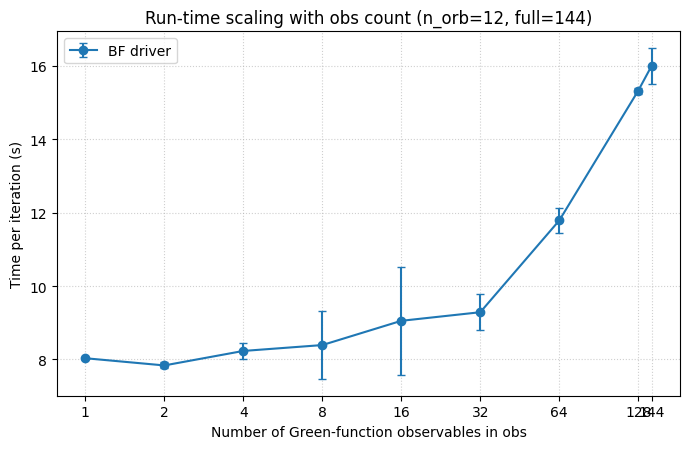

{'obs_count': array([  1,   2,   4,   8,  16,  32,  64, 128, 144]),
 'time_per_iter_mean_s': array([ 8.03372695,  7.83754849,  8.23215594,  8.3922456 ,  9.05306802,
         9.28707077, 11.78666039, 15.32271462, 16.00107862]),
 'time_per_iter_std_s': array([0.00756855, 0.08126309, 0.2256504 , 0.92864652, 1.47097234,
        0.48507485, 0.32879829, 0.07985798, 0.48586272])}

In [23]:
import time
import numpy as np
import matplotlib.pyplot as plt
from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd

# ===== 可调参数 =====
n_iter_bench = 5
n_repeat = 2
show_progress = True

# 选择用于 benchmark 的 driver（优先 BF）
def _pick_driver_for_bench():
    if "gs_bf" in globals() and "vstate_bf" in globals():
        return "BF", gs_bf, vstate_bf
    if "gs_nj" in globals() and "vstate_nj" in globals():
        return "NJ", gs_nj, vstate_nj
    if "gs_slater" in globals() and "vstate_slater" in globals():
        return "Slater", gs_slater, vstate_slater
    raise RuntimeError("未找到可用 driver/vstate，请先运行第 18/20/22 个代码块之一。")

state_tag, driver_bench, vstate_bench = _pick_driver_for_bench()
print(f"Benchmark driver = {state_tag}")

n_orb = hi.n_orbitals
full_count = n_orb * n_orb
print(f"n_orb = {n_orb}, full_count = {full_count}")

# 构造并转换单自旋（up）格林函数观测量池，共 n_orb*n_orb 个
# 这样可避免 Fixed-fermion Hilbert 上的 FermionOperator2nd 警告并提升效率
op_pool = []
for i in range(n_orb):
    for j in range(n_orb):
        key = f"Gup_{i}_{j}"
        op_raw = cdag(hi, i, sz=+1) @ c(hi, j, sz=+1)
        op_conv = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(op_raw)
        op_pool.append((key, op_conv))

counts = [1, 2, 4, 8, 16, 32, 64, 128, 144]
counts = [k for k in counts if k <= full_count]
if full_count not in counts:
    counts.append(full_count)
counts = sorted(set(counts))

old_n_samples = int(vstate_bench.n_samples)
old_n_discard = int(vstate_bench.n_discard_per_chain)
bench_n_samples = min(old_n_samples, 2**13)
vstate_bench.n_samples = bench_n_samples
vstate_bench.n_discard_per_chain = old_n_discard

warm_obs = {op_pool[0][0]: op_pool[0][1]}
_ = driver_bench.run(n_iter=1, out=nk.logging.RuntimeLog(), obs=warm_obs, show_progress=False)

records = []
try:
    for k in counts:
        obs_k = {name: op for name, op in op_pool[:k]}

        per_iter_list = []
        for rep in range(n_repeat):
            log_k = nk.logging.RuntimeLog()
            t0 = time.perf_counter()
            driver_bench.run(
                n_iter=n_iter_bench,
                out=log_k,
                obs=obs_k,
                show_progress=show_progress,
            )
            t1 = time.perf_counter()
            per_iter_list.append((t1 - t0) / n_iter_bench)

        mean_t = float(np.mean(per_iter_list))
        std_t = float(np.std(per_iter_list))
        records.append((k, mean_t, std_t))
        print(f"obs={k:3d} | time/iter={mean_t:.6f}s ± {std_t:.6f}s")

finally:
    vstate_bench.n_samples = old_n_samples
    vstate_bench.n_discard_per_chain = old_n_discard

records = np.array(records, dtype=float)
obs_counts = records[:, 0]
time_mean = records[:, 1]
time_std = records[:, 2]

plt.figure(figsize=(7.0, 4.6))
plt.errorbar(obs_counts, time_mean, yerr=time_std, marker="o", capsize=3, label=f"{state_tag} driver")
plt.xscale("log", base=2)
plt.xticks(obs_counts, [str(int(x)) for x in obs_counts], rotation=0)
plt.xlabel("Number of Green-function observables in obs")
plt.ylabel("Time per iteration (s)")
plt.title(f"Run-time scaling with obs count (n_orb={n_orb}, full={full_count})")
plt.grid(True, which="both", ls=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

bench_table = {
    "obs_count": obs_counts.astype(int),
    "time_per_iter_mean_s": time_mean,
    "time_per_iter_std_s": time_std,
}
bench_table